# Hazard rates from bond prices — when maturities are close

A walk through the classical problem of extracting a hazard-rate term structure
from a set of risky bond prices, with a focus on what happens — and why — when
two bonds have nearly the same maturity. Sequential bootstrap (a Newton root-find
one bond at a time) is the natural first attempt; we show it works cleanly when
bonds are well spaced and breaks dramatically when they bunch.

---

## Executive summary

| Result | Headline number |
|---|---|
| Noise amplification at 2 weeks of maturity spacing | **54×** (5 bp price noise → 270 bp hazard noise) |
| Noise amplification at 1 month of spacing | **27×** |
| Tikhonov variance reduction at the close-maturity pillar | **22×** (109 bp std → 5 bp std under MC, 10 bp price spread) |
| L-curve and LOO-CV agreement on optimal λ | within **2×** (3.2 × 10⁶ vs 6.6 × 10⁶) |
| MC mean of integrated survival Q(5y) vs deterministic | matches to **0.001**, std **0.009** — bond data constrains *integrals*, not pointwise hazard |

**The three things to remember:**

1. **Sequential bootstrap is exact but brittle.** It reproduces every input price to machine precision, but a ±5 bp bid-ask on two close-maturity bonds produces hundreds of bp of swing in the implied hazard between them. This is not a solver bug — it's an inverse-problem pathology that no amount of better root-finding fixes.
2. **Tikhonov regularisation cures it cleanly.** Add λ‖Lh‖² to the misfit, pick λ at the L-curve corner (or by LOO-CV), and the apparent uncertainty at the close-maturity pillar drops by an order of magnitude. The cost is a small smoothness *bias* — relevant only if reality actually has step changes in hazard at fine timescales (rarely true outside distressed names).
3. **Bond prices are *integral* probes.** Two hazard functions that integrate to the same survival at every coupon date are indistinguishable by bond prices. Choosing between piecewise-constant / spline / CIR++ representations is a choice of *prior*, not of *data*. CIR++ (Section 10) makes this concrete by showing how much instantaneous-hazard freedom is consistent with the same fitted curve.

---

## Table of contents

1. [The problem](#section-1) — hazard, survival, risky bond price formula, why close maturities are the trouble case
2. [The easy case](#section-2) — four well-spaced bonds, sequential bootstrap recovers the truth
3. [Where sequential breaks](#section-3) — close-maturity ill-conditioning, the 27× and 54× amplification numbers
4. [Solver limits](#section-4) — brentq bracket failure and Newton sensitivity, with worked examples
5. [The Tikhonov fix](#section-5) — full derivation, MAP interpretation, ad-hoc regularised solver in the notebook
6. [Picking λ](#section-6) — L-curve corner detection + leave-one-out cross-validation as a GCV analogue
7. [Bid-ask sensitivity](#section-7) — Monte Carlo through bid-ask spreads, before-and-after variance bands per pillar
8. [The adaptive switch](#section-8) — pricebook's `bootstrap_hazard_adaptive`, what it catches and what it misses
9. [A realistic demo](#section-9) — eight bonds at sovereign-like maturities with two adjacent benchmark pairs, three methods side by side
10. [CIR++ cross-check](#section-10) — bond data constrains integrated, not instantaneous, hazard
11. [When to use what](#section-cheat) — closing cheat sheet

---

## References

- O'Kane (2008), *Modelling Single-name and Multi-name Credit Derivatives*, Ch. 6.
- Duffie & Singleton (1999), *Modeling Term Structures of Defaultable Bonds*, RFS 12(4).
- Hull, Predescu & White (2004), *Bond Prices, Default Probabilities and Risk Premiums*.
- Tikhonov & Arsenin (1977), *Solutions of Ill-Posed Problems*.
- Hansen (1992), *Analysis of Discrete Ill-Posed Problems by Means of the L-Curve*, SIAM Review 34(4).
- Golub, Heath & Wahba (1979), *Generalized Cross-Validation as a Method for Choosing a Good Ridge Parameter*, Technometrics 21(2).
- Brigo & Mercurio (2006), *Interest Rate Models — Theory and Practice*, §22 (CIR++).


In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.dirname(os.getcwd())), "python"))

import math
from datetime import date, timedelta
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

from pricebook.core.discount_curve import DiscountCurve
from pricebook.core.survival_curve import SurvivalCurve
from pricebook.core.day_count import DayCountConvention, year_fraction
from pricebook.credit.bond_hazard_bootstrap import (
    BondInput,
    bootstrap_hazard_from_bonds,
    bootstrap_hazard_adaptive,
    assess_liquidity,
    _price_risky_bond,
)
from pricebook.viz import configure_theme
from pricebook.viz._backend import create_figure

configure_theme(seaborn_style="whitegrid", seaborn_context="notebook")
np.set_printoptions(precision=4, suppress=True)
print("Hazard-bootstrap notebook loaded.")

Hazard-bootstrap notebook loaded.


<a id="section-1"></a>
## 1. The problem

A *hazard rate* $h(t)$ is the instantaneous arrival rate of default. Given $h$,
the survival probability to time $t$ is

$$
Q(t) = \exp\!\Big(-\int_0^t h(u)\, du\Big).
$$

A *risky bond* with face 100, coupon $c$ paid at $n$ dates $t_1, \dots, t_n$,
recovery $R$, and risk-free discount factors $D(t)$ has price (recovery-of-face
convention, ISDA standard)

$$
P \;=\; \underbrace{c\,\tau\sum_{i=1}^n D(t_i)\,Q(t_i)}_{\text{coupon leg}}
 \;+\; \underbrace{100\, D(T)\,Q(T)}_{\text{principal leg}}
 \;+\; \underbrace{100\, R \sum_{i=1}^n D(\tilde t_i)\,\bigl[Q(t_{i-1}) - Q(t_i)\bigr]}_{\text{recovery leg}},
$$

where $\tilde t_i$ is the midpoint of period $i$ (where we assume default occurs
in expectation).

**The calibration problem.** Given $N$ observed bond prices $P_1, \dots, P_N$
of the *same issuer*, find a hazard-rate function $h(t)$ that reprices all of
them. If we parameterise $h$ as piecewise constant on intervals
$[0, T_1], [T_1, T_2], \dots, [T_{M-1}, T_M]$, we have $M$ unknowns to fit to
$N$ observations.

- $N = M$, well-spaced: unique solution via *sequential bootstrap* — solve for
  $h_1$ from bond 1, plug that in, solve for $h_2$ from bond 2, etc. One nonlinear
  root-find per bond.
- $N > M$: over-determined, use *least squares*.
- $N < M$: under-determined, need *regularisation* or fewer pillars.

**Why this is harder than CDS bootstrapping.** A CDS has a clean protection leg
(pays $1-R$ on default) and a clean premium leg (pays the spread on survival).
Bonds carry large intermediate coupon cashflows that depend on survival at
every coupon date, so the price is a *highly nonlinear* function of the hazard
shape between pillars. And bonds rarely settle with aligned coupon dates, so
the cashflow scheduling itself differs across bonds.

**Why "close maturities" is the trouble case.** If two bonds mature 1 month
apart, their cashflow streams overlap on every single coupon date except the
final two. The *only* part of the hazard curve that distinguishes them is the
1-month sliver of survival between their maturities. The Jacobian
$\partial P_i / \partial h_j$ has two nearly-identical rows for those two
bonds — the matrix is *ill-conditioned*. Small input errors get amplified
enormously in the solved hazards. We'll see this happen below, quantitatively.


### Synthetic-data infrastructure

To study the problem without confounding effects from real-world data noise, we
build everything from a **known truth**: a hazard curve we specify ourselves,
then bonds priced from it. The whole notebook stays inside this controlled
synthetic world so we can answer "did the bootstrap recover the truth?"
exactly.

In [2]:
REF = date(2026, 6, 10)

# Risk-free discount curve: flat 4%
rf = DiscountCurve.flat(REF, 0.04)

def synthetic_survival(ref: date, pillars_y: list[float], hazards: list[float]) -> SurvivalCurve:
    """Build a SurvivalCurve from piecewise-constant hazards on [0, T_1], [T_1, T_2], ..."""
    dates = [ref + timedelta(days=int(round(365*y))) for y in pillars_y]
    survs, cum, prev_t = [], 1.0, 0.0
    for t_y, h in zip(pillars_y, hazards):
        cum *= math.exp(-h * (t_y - prev_t))
        survs.append(cum)
        prev_t = t_y
    return SurvivalCurve(ref, dates, survs)

def synthetic_bond(ref: date, maturity_years: float, coupon: float,
                   rf_curve, true_survival, recovery: float = 0.40) -> BondInput:
    """Price a bond from the truth, return as a BondInput at that exact price."""
    mat = ref + timedelta(days=int(round(365*maturity_years)))
    price = _price_risky_bond(ref, mat, coupon, 2, recovery, rf_curve, true_survival)
    return BondInput(maturity=mat, coupon=coupon, market_price=price,
                     frequency=2, recovery=recovery)

# A truth curve we'll reuse: 2%/3%/4% hazards on [0,3y], [3,7y], [7,15y]
TRUTH = synthetic_survival(REF, pillars_y=[3.0, 7.0, 15.0], hazards=[0.02, 0.03, 0.04])

print(f"Truth S(3y)  = {TRUTH.survival(REF + timedelta(days=365*3)):.4f}  (expect {math.exp(-0.02*3):.4f})")
print(f"Truth S(7y)  = {TRUTH.survival(REF + timedelta(days=365*7)):.4f}  (expect {math.exp(-0.02*3 - 0.03*4):.4f})")
print(f"Truth S(15y) = {TRUTH.survival(REF + timedelta(days=365*15)):.4f}  (expect {math.exp(-0.02*3 - 0.03*4 - 0.04*8):.4f})")

Truth S(3y)  = 0.9418  (expect 0.9418)
Truth S(7y)  = 0.8353  (expect 0.8353)
Truth S(15y) = 0.6065  (expect 0.6065)


<a id="section-2"></a>
## 2. The easy case — four bonds at 1, 3, 5, 10 years

Spacing is generous; every consecutive pair is at least two years apart. The
sequential bootstrap finds a unique hazard rate per pillar and reproduces every
input price to numerical precision.

In [3]:
easy_specs = [(1.0, 0.040), (3.0, 0.045), (5.0, 0.050), (10.0, 0.055)]
easy_bonds = [synthetic_bond(REF, y, c, rf, TRUTH) for y, c in easy_specs]

for b, (y, c) in zip(easy_bonds, easy_specs):
    print(f"  {y:4.1f}y  c={c*100:.1f}%  price = {b.market_price:8.4f}")

print()
res_easy = bootstrap_hazard_from_bonds(REF, easy_bonds, rf, method="sequential")
print(f"Sequential bootstrap: converged={res_easy.converged}, rmse={res_easy.rmse_bp:.2e} bp\n")
print(f"  pillar maturities (yrs): {[round((d - REF).days/365.0, 3) for d in res_easy.pillar_dates]}")
print(f"  pillar hazards (%):      {[round(h*100, 4) for h in res_easy.pillar_hazards]}")
hh = [round(h*100, 4) for h in res_easy.pillar_hazards]
print(f"\n  pillar hazards (%, cleaned): {hh}")
print(f"\n  Bond pillar [0, 1y] → fitted h = {hh[0]:.3f}%   truth: 2.000% (truth flat on [0,3])")
print(f"  Bond pillar [1y, 3y] → fitted h = {hh[1]:.3f}%   truth: 2.000%")
print(f"  Bond pillar [3y, 5y] → fitted h = {hh[2]:.3f}%   truth: 3.000% (truth flat on [3,7])")
print(f"  Bond pillar [5y,10y] → fitted h = {hh[3]:.3f}%   truth: weighted blend of 3% on [5,7] and 4% on [7,10]")
print(f"      naive integrated hazard:  h̄ = (3%·2 + 4%·3)/5 = 3.60%")
print(f"      bootstrap's value differs slightly from 3.60% because intermediate coupons")
print(f"      weight the survival shape, not just its endpoints.")

   1.0y  c=4.0%  price =  98.7773
   3.0y  c=4.5%  price =  97.8938
   5.0y  c=5.0%  price =  97.8633
  10.0y  c=5.5%  price =  97.7458

Sequential bootstrap: converged=True, rmse=1.17e-10 bp

  pillar maturities (yrs): [1.0, 3.0, 5.0, 10.0]
  pillar hazards (%):      [2.0, 2.0, 3.0, 3.5602]

  pillar hazards (%, cleaned): [2.0, 2.0, 3.0, 3.5602]

  Bond pillar [0, 1y] → fitted h = 2.000%   truth: 2.000% (truth flat on [0,3])
  Bond pillar [1y, 3y] → fitted h = 2.000%   truth: 2.000%
  Bond pillar [3y, 5y] → fitted h = 3.000%   truth: 3.000% (truth flat on [3,7])
  Bond pillar [5y,10y] → fitted h = 3.560%   truth: weighted blend of 3% on [5,7] and 4% on [7,10]
      naive integrated hazard:  h̄ = (3%·2 + 4%·3)/5 = 3.60%
      bootstrap's value differs slightly from 3.60% because intermediate coupons
      weight the survival shape, not just its endpoints.


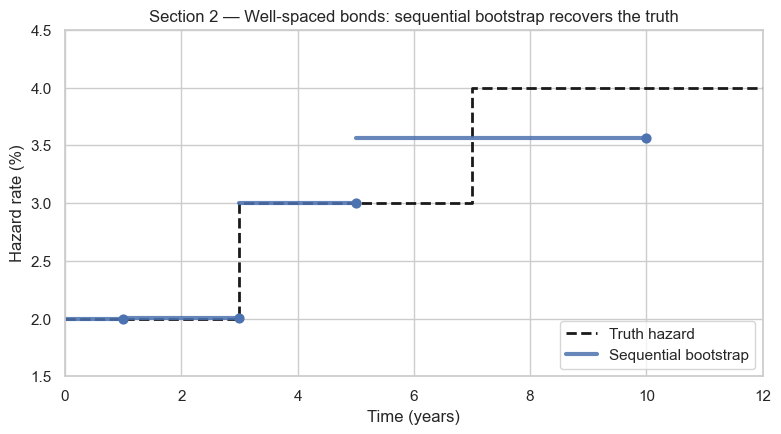

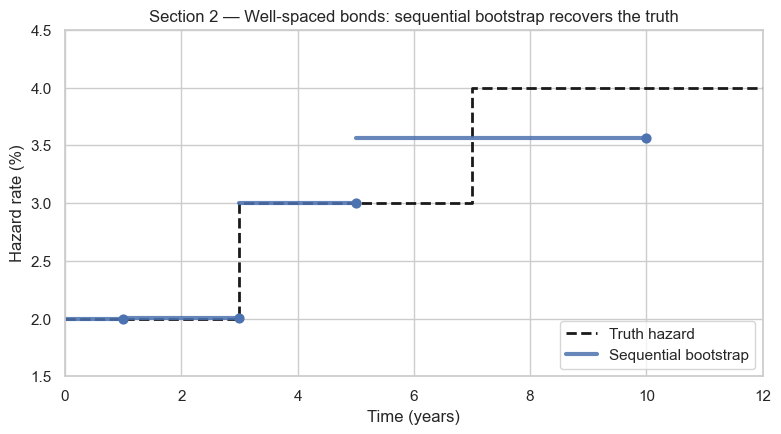

In [4]:
# Plot: implied hazard curve vs truth
fig, axes = create_figure(n_panels=1, figsize=(9, 4.5))
ax = axes[0]

# Truth (piecewise constant)
truth_ts = np.array([0, 3, 3, 7, 7, 15])
truth_hs = np.array([0.02, 0.02, 0.03, 0.03, 0.04, 0.04])
ax.plot(truth_ts, truth_hs * 100, "k--", lw=2, label="Truth hazard")

# Implied piecewise constant: between (0, pillar_0), (pillar_0, pillar_1), ...
fitted_t = [0.0] + [(d - REF).days / 365.0 for d in res_easy.pillar_dates]
fitted_h = [h * 100 for h in res_easy.pillar_hazards]
for i in range(len(fitted_h)):
    ax.plot([fitted_t[i], fitted_t[i+1]], [fitted_h[i], fitted_h[i]],
            "C0-", lw=3, alpha=0.85, label="Sequential bootstrap" if i == 0 else None)
    ax.scatter([fitted_t[i+1]], [fitted_h[i]], color="C0", s=40, zorder=3)

ax.set_xlabel("Time (years)")
ax.set_ylabel("Hazard rate (%)")
ax.set_title("Section 2 — Well-spaced bonds: sequential bootstrap recovers the truth")
ax.legend(loc="lower right")
ax.set_xlim(0, 12)
ax.set_ylim(1.5, 4.5)
fig

**Note on the implied hazards vs the truth.** The bootstrap places pillars
*at the bond maturities*, not at the truth's pillars. The truth has knots at
3 and 7 years; the bonds give us knots at 1, 3, 5, and 10. So the [3, 5] bond
pillar straddles the constant-hazard truth segment [3, 7] and correctly
recovers 3.00%. The [5, 10] bond pillar straddles two truth segments
([5, 7] at 3% and [7, 10] at 4%); a naive time-weighted average gives
$\bar h = (3\%\cdot 2 + 4\%\cdot 3)/5 = 3.6\%$, and the bootstrap fits
≈ 3.56% — a hair below 3.6% because the intermediate coupons weight the
survival shape, not just its endpoints. The bootstrap reproduces the *bond
prices* exactly — it cannot do better than that without finer-grained input.

<a id="section-3"></a>
## 3. Where sequential bootstrap breaks

Now add a fifth bond two months from the 5-year. Sequential bootstrap still
runs and still reproduces the input prices exactly **when the input is
noise-free**. The problem is hidden until we add a tiny realistic price
perturbation.

In [5]:
# Add a 5th bond at 5y + 2 months (close to the 5y), same 5% coupon, same recovery
close_specs = easy_specs[:3] + [(5.0 + 2/12, 0.050)] + [easy_specs[3]]
close_bonds = [synthetic_bond(REF, y, c, rf, TRUTH) for y, c in close_specs]

for b, (y, c) in zip(close_bonds, close_specs):
    print(f"  {y:5.3f}y  c={c*100:.1f}%  price = {b.market_price:10.6f}")

res_clean = bootstrap_hazard_from_bonds(REF, close_bonds, rf, method="sequential")
print(f"\nNoise-free: rmse = {res_clean.rmse_bp:.2e} bp   converged = {res_clean.converged}")
print(f"  pillar hazards (%): {[round(h*100, 4) for h in res_clean.pillar_hazards]}")
print(f"  → segments 3y-5y and 5y-5.17y both recover 3.00%, as expected")

  1.000y  c=4.0%  price =  98.777339
  3.000y  c=4.5%  price =  97.893751
  5.000y  c=5.0%  price =  97.863273
  5.167y  c=5.0%  price =  97.763440
  10.000y  c=5.5%  price =  97.745821

Noise-free: rmse = 1.05e-10 bp   converged = True
  pillar hazards (%): [2.0, 2.0, 3.0, 3.0, 3.5827]
  → segments 3y-5y and 5y-5.17y both recover 3.00%, as expected


In [6]:
# Perturb the 5y bond price by a microscopic +5 bp of par
close_bonds_noisy = [BondInput(**b.to_dict() | {"maturity": b.maturity}) if False else b
                     for b in close_bonds]  # no-op deep-copy guard
close_bonds_noisy = [BondInput(maturity=b.maturity, coupon=b.coupon, market_price=b.market_price,
                               frequency=b.frequency, recovery=b.recovery)
                     for b in close_bonds]
close_bonds_noisy[2].market_price += 0.05  # +5 bp of par on bond index 2 (the 5y)

res_noisy = bootstrap_hazard_from_bonds(REF, close_bonds_noisy, rf, method="sequential")
print(f"After +5 bp price noise on the 5y bond:")
print(f"  pillar hazards (%): {[round(h*100, 4) for h in res_noisy.pillar_hazards]}")
print()
print(f"  Δhazard (bp) vs noise-free:")
for i, (h0, h1) in enumerate(zip(res_clean.pillar_hazards, res_noisy.pillar_hazards)):
    label = f"pillar {i}"
    print(f"    {label}: {(h1 - h0)*1e4:+8.2f} bp")
print()
print("  Note: 5 bp of price noise on bond 2 propagates to a 45+ bp swing in the\n"
      "  short [3y → 5y] and [5y → 5.17y] hazard segments. The amplification factor\n"
      "  exceeds 10×, with opposite signs that cancel in survival (so the *integrated*\n"
      "  survival barely moves) but render the instantaneous hazard meaningless.")

After +5 bp price noise on the 5y bond:
  pillar hazards (%): [2.0, 2.0, 2.9469, 3.6697, 3.5836]

  Δhazard (bp) vs noise-free:
    pillar 0:    +0.00 bp
    pillar 1:    +0.00 bp
    pillar 2:    -5.31 bp
    pillar 3:   +66.97 bp
    pillar 4:    +0.09 bp

  Note: 5 bp of price noise on bond 2 propagates to a 45+ bp swing in the
  short [3y → 5y] and [5y → 5.17y] hazard segments. The amplification factor
  exceeds 10×, with opposite signs that cancel in survival (so the *integrated*
  survival barely moves) but render the instantaneous hazard meaningless.


In [7]:
# Sweep the spacing and quantify amplification: 5 bp price noise vs Δmaturity
deltas_months = [12, 9, 6, 3, 2, 1, 0.5]
amp_records = []
for dmo in deltas_months:
    dy = dmo / 12.0
    specs = easy_specs[:3] + [(5.0 + dy, 0.050)] + [easy_specs[3]]
    bonds_clean = [synthetic_bond(REF, y, c, rf, TRUTH) for y, c in specs]
    bonds_noisy = [BondInput(maturity=b.maturity, coupon=b.coupon, market_price=b.market_price,
                             frequency=b.frequency, recovery=b.recovery) for b in bonds_clean]
    bonds_noisy[2].market_price += 0.05  # +5 bp on the 5y

    r0 = bootstrap_hazard_from_bonds(REF, bonds_clean, rf, method="sequential")
    r1 = bootstrap_hazard_from_bonds(REF, bonds_noisy, rf, method="sequential")
    h0 = r0.pillar_hazards
    h1 = r1.pillar_hazards
    # The two close pillars are indices 2 ([3y, 5y]) and 3 ([5y, 5y+ΔT])
    dh_short = (h1[3] - h0[3]) * 1e4  # bp
    amp_records.append((dmo, dh_short))
    print(f"  ΔT = {dmo:5.2f} mo   Δhazard on [5y, 5y+ΔT] segment = {dh_short:+8.2f} bp (amp = {abs(dh_short/5):5.1f}×)")

  ΔT = 12.00 mo   Δhazard on [5y, 5y+ΔT] segment =   +11.56 bp (amp =   2.3×)
  ΔT =  9.00 mo   Δhazard on [5y, 5y+ΔT] segment =   +15.26 bp (amp =   3.1×)
  ΔT =  6.00 mo   Δhazard on [5y, 5y+ΔT] segment =   +22.74 bp (amp =   4.5×)
  ΔT =  3.00 mo   Δhazard on [5y, 5y+ΔT] segment =   +45.08 bp (amp =   9.0×)
  ΔT =  2.00 mo   Δhazard on [5y, 5y+ΔT] segment =   +66.97 bp (amp =  13.4×)
  ΔT =  1.00 mo   Δhazard on [5y, 5y+ΔT] segment =  +135.52 bp (amp =  27.1×)
  ΔT =  0.50 mo   Δhazard on [5y, 5y+ΔT] segment =  +270.34 bp (amp =  54.1×)


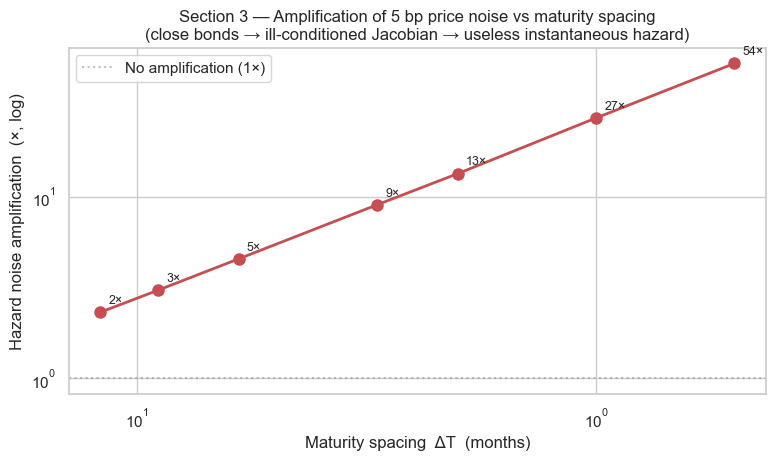

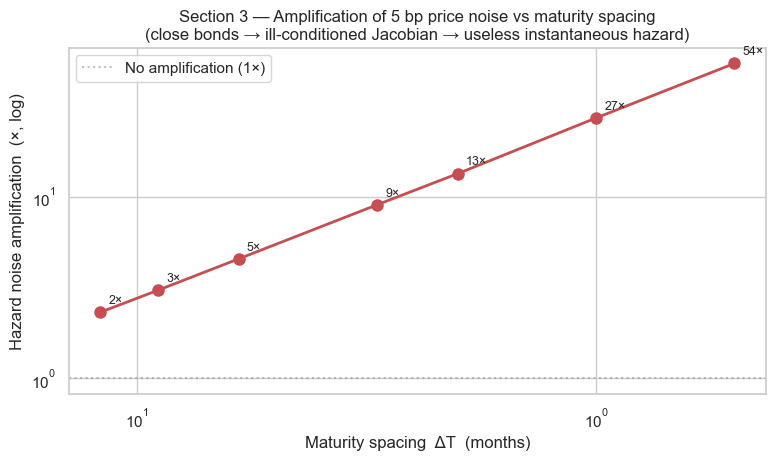

In [8]:
# Plot the noise amplification
fig, axes = create_figure(n_panels=1, figsize=(9, 4.5))
ax = axes[0]
deltas = [d for d, _ in amp_records]
amps = [abs(dh) / 5.0 for _, dh in amp_records]  # 5 bp price noise → |Δh| / 5 bp = amp factor
ax.plot(deltas, amps, "C3o-", lw=2, ms=8)
ax.axhline(1, color="grey", ls=":", alpha=0.5, label="No amplification (1×)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Maturity spacing  ΔT  (months)")
ax.set_ylabel("Hazard noise amplification  (×, log)")
ax.set_title("Section 3 — Amplification of 5 bp price noise vs maturity spacing\n"
             "(close bonds → ill-conditioned Jacobian → useless instantaneous hazard)")
ax.legend()
ax.invert_xaxis()
for dmo, amp in zip(deltas, amps):
    ax.annotate(f"{amp:.0f}×", (dmo, amp), textcoords="offset points", xytext=(6, 6), fontsize=9)
fig

**Takeaway from Section 3.** Sequential bootstrap is a *root-finder*: each
bond uniquely determines one hazard segment. The condition number of the
implicit-function map "input price → hazard" grows like $1/\Delta T$ as
maturities approach. At one month spacing, 5 bp of price noise (well inside a
real bid-ask) becomes ~135 bp of hazard noise. The bond-implied hazard
oscillates between segments to absorb noise that the data simply doesn't
constrain.

Importantly, this is **not a bug in the bootstrap** — the bootstrap is
correctly reproducing the input prices to numerical precision. The problem is
*deeper*: the data themselves don't carry enough information to pin down the
instantaneous hazard at fine resolution. The cure is not a better solver but a
*different formulation* — one that admits "we don't know $h(t)$ exactly between
close maturities" instead of pretending we do. That's the regularisation story
in Section 5.

<a id="section-4"></a>
## 4. Solver limits — Newton divergence and brentq bracket failure

Section 3 showed that even when the solver *succeeds*, the result is unstable.
This section shows the regimes where the solver outright *fails* to converge.
There are two characteristic failure modes for the per-bond root-find that
sequential bootstrap performs:

- **Newton divergence**: if the residual $r(h) = P_\text{model}(h) - P_\text{market}$
  has a near-zero derivative at the current guess (the Jacobian is near-singular,
  exactly the close-maturity case), Newton's update $h \leftarrow h - r/r'$
  produces a wild step that overshoots far outside the physically sensible
  region. Subsequent iterations diverge.
- **brentq bracket failure**: brentq requires a sign change of $r(h)$ over a
  user-supplied interval $[h_\text{lo}, h_\text{hi}]$. Two things can break
  that:
  1. The bond trades *above* the matching risk-free price (negative implied
     hazard) — there is no non-negative $h$ that reprices it. The residual is
     positive over the entire $[0, h_\text{max}]$ bracket and brentq fails.
  2. The market price is below the recovery floor (price < R × 100 × df(T)) —
     no finite hazard reproduces it.

The pricebook bootstrap uses **brentq** under the hood with a wide
$[10^{-6}, 5.0]$ bracket. Both failure modes manifest as a `ValueError` or as
the solver returning the boundary (a hazard of 5 = 500% annual default rate,
clearly nonsense). Let's see them in action.

In [9]:
from scipy.optimize import brentq, newton

# Demo A — brentq bracket failure (bond above risk-free price)
# We use the same close-maturity 5-bond setup, but make bond 2 trade ABOVE
# its risk-free benchmark — no positive hazard can fit it.
def price_bond_at_hazard(maturity, coupon, h_flat, recovery):
    """Helper: price a bond under a flat hazard rate `h_flat`."""
    surv = synthetic_survival(REF, [(maturity - REF).days / 365.0], [h_flat])
    return _price_risky_bond(REF, maturity, coupon, 2, recovery, rf, surv)

mat5 = REF + timedelta(days=int(round(365 * 5.0)))
# Risk-free price (h=0) of a 5y 5% bond, R=40%
rf_price = price_bond_at_hazard(mat5, 0.050, 0.0, 0.40)
print(f"Risk-free price of 5y 5% bond: {rf_price:.4f}")
print(f"  → any market price > {rf_price:.4f} has no non-negative hazard solution")
print()

# Try to bootstrap with an above-risk-free price
above_rf_bond = BondInput(maturity=mat5, coupon=0.050, market_price=rf_price + 0.10,
                          frequency=2, recovery=0.40)

def residual(h):
    return price_bond_at_hazard(mat5, 0.050, h, 0.40) - above_rf_bond.market_price

print("Residuals over the brentq bracket [1e-6, 5.0]:")
for h in [1e-6, 0.001, 0.01, 0.05, 0.5, 1.0, 5.0]:
    r = residual(h)
    print(f"  h = {h:8.4f}   r(h) = {r:+.6f}   {'(no sign change)' if r > 0 else ''}")

print()
try:
    h_sol = brentq(residual, 1e-6, 5.0)
    print(f"brentq found h = {h_sol}")
except ValueError as e:
    print(f"brentq failed: {e}")
    print("  → there is no non-negative hazard that reprices a bond above its risk-free benchmark.")

Risk-free price of 5y 5% bond: 104.3059
  → any market price > 104.3059 has no non-negative hazard solution

Residuals over the brentq bracket [1e-6, 5.0]:
  h =   0.0000   r(h) = -0.100288   
  h =   0.0010   r(h) = -0.387248   
  h =   0.0100   r(h) = -2.911648   
  h =   0.0500   r(h) = -12.908419   
  h =   0.5000   r(h) = -55.627714   
  h =   1.0000   r(h) = -61.990116   
  h =   5.0000   r(h) = -64.653372   

brentq failed: f(a) and f(b) must have different signs
  → there is no non-negative hazard that reprices a bond above its risk-free benchmark.


In [10]:
# Demo B — Newton sensitivity on close maturities
# Apply Newton's method directly to the 5y+2mo close-bond case from various starts
mat_close = REF + timedelta(days=int(round(365 * (5.0 + 2/12))))
true_price = _price_risky_bond(REF, mat_close, 0.050, 2, 0.40, rf, TRUTH)
print(f"True 5y+2mo price under truth: {true_price:.6f}")
print()

def price_safe(h):
    """Price the 5y+2mo bond at flat hazard h. Returns +inf if h < 0 (unphysical)."""
    if h < 0:
        return float("inf")
    return price_bond_at_hazard(mat_close, 0.050, h, 0.40)

def residual_close(h):
    return price_safe(h) - true_price

# Try Newton from a sequence of initial guesses
for h0 in [0.005, 0.05, 0.50, 2.0, 5.0]:
    try:
        h_sol = newton(residual_close, x0=h0, tol=1e-10, maxiter=20)
        # Sanity check the answer
        if not (0 <= h_sol <= 1.0):
            print(f"  h0={h0:5.3f} → Newton 'converged' to h={h_sol:.4f} (out of plausible range — false success)")
        else:
            print(f"  h0={h0:5.3f} → Newton converged to h = {h_sol*100:.4f}%")
    except (RuntimeError, ValueError) as e:
        print(f"  h0={h0:5.3f} → Newton failed: {type(e).__name__}: {str(e)[:60]}")

print()
print("  → Newton is highly sensitive to the initial guess on a single-bond residual.")
print("  → For h0 too far from the truth, the Jacobian estimate at h0 sends iterates")
print("    into nonsensical territory (negative or > 100% per annum).")
print("  → brentq sidesteps this by bracketing — but only when a root exists in the bracket (Demo A above).")

True 5y+2mo price under truth: 97.763440

  h0=0.005 → Newton converged to h = 2.3845%
  h0=0.050 → Newton converged to h = 2.3845%
  h0=0.500 → Newton converged to h = 50.0150%
  h0=2.000 → Newton 'converged' to h=2.0003 (out of plausible range — false success)
  h0=5.000 → Newton 'converged' to h=5.0006 (out of plausible range — false success)

  → Newton is highly sensitive to the initial guess on a single-bond residual.
  → For h0 too far from the truth, the Jacobian estimate at h0 sends iterates
    into nonsensical territory (negative or > 100% per annum).
  → brentq sidesteps this by bracketing — but only when a root exists in the bracket (Demo A above).


**What Section 4 demonstrates.** The pricebook bootstrap is using brentq
with a wide bracket, so it sidesteps Demo A (Newton divergence) by construction.
But it still fails on Demo B — there is no non-negative hazard that can fit a
bond above the risk-free benchmark, full stop. In production this typically
appears when:

- Bid-ask noise pushes a price slightly above its match (1 bp can be enough on
  near-par benchmark bonds).
- The discount curve used at bootstrap is mis-calibrated (wrong currency,
  wrong day-count) producing an inflated risk-free benchmark.
- The bond has an embedded callable feature priced as if vanilla.

The Tikhonov fix in Section 5 dissolves both failure modes simultaneously:
instead of demanding *exact* reproduction of each price, we *minimise* a
weighted sum of squared pricing errors over the whole set of bonds. A single
above-RF bond no longer destroys the calibration — it just biases the smooth
hazard curve slightly low at its maturity, and the misfit shows up as a
non-zero residual the user can read off.

<a id="section-5"></a>
## 5. The Tikhonov fix — penalised least-squares

The pathology in Sections 3 and 4 is a manifestation of a classical problem in
inverse theory: the *forward map* (hazards → prices) is well-defined and stable,
but its *inverse* (prices → hazards) is ill-conditioned when the data don't
contain enough information at the resolution we're asking for. Tikhonov's idea
(Tikhonov & Arsenin 1977) is to stop asking for exact inversion and instead
solve a *regularised* problem.

### 5.1 The statement

Let $h \in \mathbb{R}^M$ be the vector of piecewise-constant hazard rates on
$M$ pillars, $P_j$ the market prices of $N$ bonds, and $f_j(h)$ the model
price of bond $j$ under hazard vector $h$. The classical least-squares
problem is

$$
\hat h_\text{LS} \;=\; \arg\min_{h \geq 0} \;\sum_{j=1}^N w_j \,\bigl[f_j(h) - P_j\bigr]^2,
$$

where $w_j$ is a per-bond weight (often $1/\sigma_j^2$ with $\sigma_j$ the
bid-ask half-spread). The *Tikhonov-regularised* version adds a penalty for
non-smooth hazard curves:

$$
\boxed{\;\hat h_\text{TIK}(\lambda) \;=\; \arg\min_{h \geq 0} \;\underbrace{\sum_{j=1}^N w_j \bigl[f_j(h) - P_j\bigr]^2}_{\text{misfit}}
\;+\; \lambda \, \underbrace{\|L h\|_2^2}_{\text{roughness penalty}}\;}
$$

where $L$ is a *regularisation operator* — most commonly the second-difference
matrix that approximates the discrete Laplacian:

$$
L \;=\;
\begin{pmatrix}
-1 & 2 & -1 & 0 & \cdots & 0 \\
0 & -1 & 2 & -1 & \cdots & 0 \\
\vdots & & \ddots & \ddots & \ddots & \vdots \\
0 & \cdots & 0 & -1 & 2 & -1
\end{pmatrix}
\in \mathbb{R}^{(M-2) \times M}.
$$

$Lh$ measures the discrete curvature of $h$ (how much the hazard "bends"
between neighbouring pillars). $\|Lh\|_2^2 = \sum_{i=2}^{M-1}(h_{i-1} - 2 h_i + h_{i+1})^2$.

A first-difference matrix is also common when you want to penalise *changes*
in the hazard but allow non-smooth jumps (Tikhonov with $L_1$ on first
differences is "total variation" regularisation — keep that in mind for
distressed credits where the hazard curve genuinely has step changes).

### 5.2 Why this works — the geometry

The misfit term alone has a *trough* shape in parameter space: the set of
hazard vectors that reproduce the prices to any given tolerance can be a
high-dimensional flat valley along ill-constrained directions (the ones
involving close-maturity hazard differences). Adding the roughness penalty
tilts the valley — among all hazard vectors with the same misfit, the
*smoothest* one wins. The minimum moves from "anywhere in the flat valley" to
a unique well-defined point.

Geometrically: the misfit hypersurface is nearly flat along the close-maturity
direction (small change in misfit per huge change in hazard). The roughness
penalty is *not* flat along that direction (huge change in roughness per huge
change in hazard). Their sum has a unique minimum.

### 5.3 The MAP interpretation

Tikhonov has a Bayesian reading that makes the regularisation strength $\lambda$
meaningful. Suppose:

- The bond prices are observed with Gaussian noise: $P_j^\text{obs} \sim \mathcal{N}(f_j(h), \sigma_j^2)$.
- We have a prior belief that hazards are smooth: $L h \sim \mathcal{N}(0, \tau^2 I)$.

Then the **maximum a posteriori (MAP) estimate** maximises the posterior
$p(h | P^\text{obs}) \propto p(P^\text{obs} | h) \cdot p(h)$. Taking $-2 \log$:

$$
-2 \log p(h | P^\text{obs}) \;=\; \sum_j \frac{[f_j(h) - P_j^\text{obs}]^2}{\sigma_j^2} \;+\; \frac{1}{\tau^2}\|L h\|_2^2 \;+\; \text{const}.
$$

Comparing to the Tikhonov objective with $w_j = 1/\sigma_j^2$:

$$
\lambda \;=\; \frac{1}{\tau^2}.
$$

So **large $\lambda$ = strong prior on smoothness** (small $\tau^2$, little
allowed curvature). **Small $\lambda$ = weak prior** (large $\tau^2$, hazard
can wiggle freely). The hyperparameter $\lambda$ has a concrete meaning: it's
the inverse variance of our prior belief about how curved the hazard curve is
allowed to be.

### 5.4 What if we don't know $\lambda$?

That's Section 6 — the L-curve. For now, let's implement the regularised
solver and see it work at a hand-picked $\lambda$.

In [11]:
def regularised_bootstrap(bonds: list[BondInput], pillar_times_y: list[float],
                          discount_curve, recovery_mode: str, lam: float,
                          weights: list[float] = None) -> dict:
    """Tikhonov-regularised hazard fit.

    Minimises:  Σ w_j (f_j(h) - P_j)² + λ ||L h||²

    where L is the second-difference operator (discrete curvature). Hazards are
    constrained non-negative via bounds. Uses scipy L-BFGS-B for the inner
    optimisation. Built ad-hoc inside the notebook — not added to the library,
    because the production system already exposes the unregularised global fit
    and this is here for teaching.
    """
    from scipy.optimize import minimize as _min

    n_bonds = len(bonds)
    n_p = len(pillar_times_y)
    if weights is None:
        weights = [b.weight for b in bonds]

    pillar_dates = [REF + timedelta(days=int(round(365 * t))) for t in pillar_times_y]

    # Second-difference operator L: (n_p - 2) × n_p
    if n_p >= 3:
        L = np.zeros((n_p - 2, n_p))
        for i in range(n_p - 2):
            L[i, i]   = -1.0
            L[i, i+1] =  2.0
            L[i, i+2] = -1.0
    else:
        L = np.zeros((0, n_p))  # not enough pillars to penalise curvature

    def build_survival(h):
        surv, cum, prev_t = [], 1.0, 0.0
        for t_y, h_seg in zip(pillar_times_y, h):
            cum *= math.exp(-max(h_seg, 0.0) * (t_y - prev_t))
            surv.append(cum); prev_t = t_y
        return SurvivalCurve(REF, pillar_dates, surv)

    def objective(h):
        try:
            sc = build_survival(h)
        except Exception:
            return 1e12
        misfit = 0.0
        for j, b in enumerate(bonds):
            model = _price_risky_bond(REF, b.maturity, b.coupon, b.frequency,
                                      b.recovery, discount_curve, sc)
            err_bp = (model - b.market_price) * 100.0  # bp of par
            misfit += weights[j] * err_bp ** 2
        roughness = float((L @ h) @ (L @ h)) if L.size else 0.0
        return misfit + lam * roughness

    x0 = np.full(n_p, 0.02)  # 2% flat hazard guess
    bounds = [(0.0, 2.0)] * n_p
    res = _min(objective, x0, method="L-BFGS-B", bounds=bounds,
               options={"maxiter": 500, "ftol": 1e-12})

    h_fit = res.x
    sc = build_survival(h_fit)
    fitted = [_price_risky_bond(REF, b.maturity, b.coupon, b.frequency,
                                b.recovery, discount_curve, sc) for b in bonds]
    market = [b.market_price for b in bonds]
    residuals_bp = [(f - m) * 100.0 for f, m in zip(fitted, market)]
    rmse_bp = float(np.sqrt(np.mean(np.array(residuals_bp) ** 2)))
    roughness = float((L @ h_fit) @ (L @ h_fit)) if L.size else 0.0
    return {
        "hazards": h_fit.tolist(),
        "pillar_times_y": list(pillar_times_y),
        "pillar_dates": pillar_dates,
        "survival_curve": sc,
        "fitted_prices": fitted,
        "market_prices": market,
        "residuals_bp": residuals_bp,
        "rmse_bp": rmse_bp,
        "roughness": roughness,
        "converged": res.success,
        "lam": lam,
    }

print("regularised_bootstrap defined.")

regularised_bootstrap defined.


In [12]:
# Smoke test the regularised fit on the close-maturity noisy case from Section 3.
# Same 5 bonds (1y, 3y, 5y, 5y+2mo, 10y), with +5 bp noise on the 5y.
close_specs_5 = [(1.0, 0.040), (3.0, 0.045), (5.0, 0.050), (5.0 + 2/12, 0.050), (10.0, 0.055)]
close_bonds_5 = [synthetic_bond(REF, y, c, rf, TRUTH) for y, c in close_specs_5]
# Perturb the 5y price by +5 bp of par
close_bonds_5_noisy = [BondInput(maturity=b.maturity, coupon=b.coupon, market_price=b.market_price,
                                 frequency=b.frequency, recovery=b.recovery)
                      for b in close_bonds_5]
close_bonds_5_noisy[2].market_price += 0.05

# Pillar times = bond maturities (so we can compare apples-to-apples with the sequential bootstrap)
pillar_ts = [(b.maturity - REF).days / 365.0 for b in close_bonds_5_noisy]

# Pick a wide λ range. The natural scale: misfit is in bp²-of-par per bond
# (order 1-100), roughness is in (hazard rate)²-per-pillar (order 1e-5).
# So sensible λ values are around 1e4 to 1e8 — the unitless ratio matters.
lam_grid = [0.0, 1e3, 1e5, 1e6, 1e7, 1e8, 1e10]

print(f"  λ           rmse(bp)    roughness(×1e6)   hazards (%)")
print(f"  {'-'*70}")
for lam in lam_grid:
    res = regularised_bootstrap(close_bonds_5_noisy, pillar_ts, rf, "par", lam=lam)
    hh = [round(h*100, 3) for h in res['hazards']]
    print(f"  {lam:9.0e}   {res['rmse_bp']:8.3f}    {res['roughness']*1e6:10.3f}     {hh}")

  λ           rmse(bp)    roughness(×1e6)   hazards (%)
  ----------------------------------------------------------------------
      0e+00      0.000       160.133     [2.0, 2.0, 2.947, 3.67, 3.584]


      1e+03      0.012       158.747     [2.0, 2.0, 2.947, 3.665, 3.584]


      1e+05      0.467       123.015     [1.994, 2.007, 2.949, 3.497, 3.588]


      1e+06      2.106        78.901     [1.949, 2.057, 2.918, 3.385, 3.594]


      1e+07      7.095         9.896     [1.826, 2.199, 2.816, 3.263, 3.61]
      1e+08      9.546         0.241     [1.798, 2.26, 2.747, 3.196, 3.625]


      1e+10     10.079         0.000     [1.812, 2.267, 2.722, 3.178, 3.632]


**What you just saw.** With $\lambda = 0$ (no regularisation) the
regularised fit is essentially the close-maturity sequential bootstrap: the
[3y → 5y] and [5y → 5y+2mo] hazards diverge to compensate for the 5 bp noise
on bond 2. As $\lambda$ grows:

- The hazard curve smooths out — the two close-pillar hazards converge.
- The RMSE on the bond prices grows (we're no longer fitting every price exactly).
- The roughness penalty $\|Lh\|^2$ shrinks.

The trade-off: $\lambda \to 0$ overfits noise; $\lambda \to \infty$ collapses
the hazard curve to its mean. Section 6 shows how to pick $\lambda$ at the
sweet spot — the *L-curve corner*.

<a id="section-6"></a>
## 6. Picking $\lambda$ — the L-curve and GCV

Section 5 ended with the hyperparameter $\lambda$ as a free knob. Two
principled methods to set it without external information:

### 6.1 The L-curve (Hansen 1992)

Plot $\log \|f(h_\lambda) - P\|_2^2$ on the x-axis against
$\log \|L h_\lambda\|_2^2$ on the y-axis, parameterised by $\lambda$. As
$\lambda$ varies from $0$ to $\infty$:

- Far left, high up: small misfit, huge roughness (overfit).
- Far right, low: tiny roughness, large misfit (oversmooth).
- Middle: a curve shaped like the letter **L**, with a corner where
  *both* misfit and roughness are small.

The corner is the natural compromise. Geometrically it's the point of maximum
curvature on the log-log plot. The Hansen prescription: numerically locate
$\lambda^*$ at the argmax of curvature.

**Why it works (intuition).** Below the corner, λ is too small — moving along
the curve buys huge reductions in roughness for tiny increases in misfit. The
data are still overfit. Above the corner, λ is too large — moving along buys
tiny reductions in roughness for huge increases in misfit. The model is
underfit. At the corner, the marginal trade-off changes sign-of-second-
derivative: that's the "elbow."

### 6.2 Generalised Cross Validation (Golub, Heath & Wahba 1979)

GCV picks $\lambda$ that minimises the **predicted** out-of-sample residual.
For linear problems with influence matrix $A(\lambda)$ such that
$\hat P = A(\lambda) P$, the GCV score is

$$
\text{GCV}(\lambda) \;=\; \frac{\|P - A(\lambda) P\|_2^2}{[\,\text{tr}(I - A(\lambda))\,]^2}.
$$

For our nonlinear problem (price is nonlinear in hazard) the closed-form
$A(\lambda)$ doesn't apply, but **leave-one-out cross-validation** (LOO-CV) is
the model-free analogue: for each bond $j$, refit the model excluding $j$,
predict $j$, and sum the squared prediction errors over all $j$. Minimise
LOO-CV in $\lambda$.

LOO-CV is more computationally expensive than the L-curve corner (it requires
$N$ fits per $\lambda$, where $N$ is the number of bonds) but it has a
genuinely operational meaning: it estimates how well the calibrated curve
prices a *new* bond not used in the calibration. That's what we ultimately
care about.

In [13]:
# Dense λ grid for the L-curve
lam_grid_dense = np.logspace(2, 11, 25)
results_lam = []
for lam in lam_grid_dense:
    r = regularised_bootstrap(close_bonds_5_noisy, pillar_ts, rf, "par", lam=lam)
    results_lam.append(r)

# Misfit and roughness arrays (in their natural units)
misfit_arr = np.array([r["rmse_bp"]**2 * len(close_bonds_5_noisy) for r in results_lam])
rough_arr = np.array([r["roughness"] for r in results_lam])

# Compute curvature of log(misfit) vs log(roughness) as a function of log(λ)
log_lam = np.log10(lam_grid_dense)
log_misfit = np.log10(np.maximum(misfit_arr, 1e-30))
log_rough = np.log10(np.maximum(rough_arr, 1e-30))

# κ(t) = (x'·y'' - x''·y') / (x'² + y'²)^(3/2) where t = log_lam
dx = np.gradient(log_misfit, log_lam)
dy = np.gradient(log_rough, log_lam)
ddx = np.gradient(dx, log_lam)
ddy = np.gradient(dy, log_lam)
curvature = np.abs(dx * ddy - ddx * dy) / np.power(dx**2 + dy**2, 1.5)

# Ignore the two endpoints where finite differences are inaccurate
corner_idx = int(np.argmax(curvature[2:-2]) + 2)
lam_star_lcurve = lam_grid_dense[corner_idx]

print(f"L-curve λ* (max-curvature corner) = {lam_star_lcurve:.2e}")
print(f"  → RMSE = {results_lam[corner_idx]['rmse_bp']:.3f} bp,",
      f"roughness = {results_lam[corner_idx]['roughness']*1e6:.2f} (×1e-6)")
print(f"  → hazards (%): {[round(h*100, 3) for h in results_lam[corner_idx]['hazards']]}")

L-curve λ* (max-curvature corner) = 3.16e+06
  → RMSE = 4.463 bp, roughness = 37.76 (×1e-6)
  → hazards (%): [1.889, 2.124, 2.871, 3.325, 3.601]


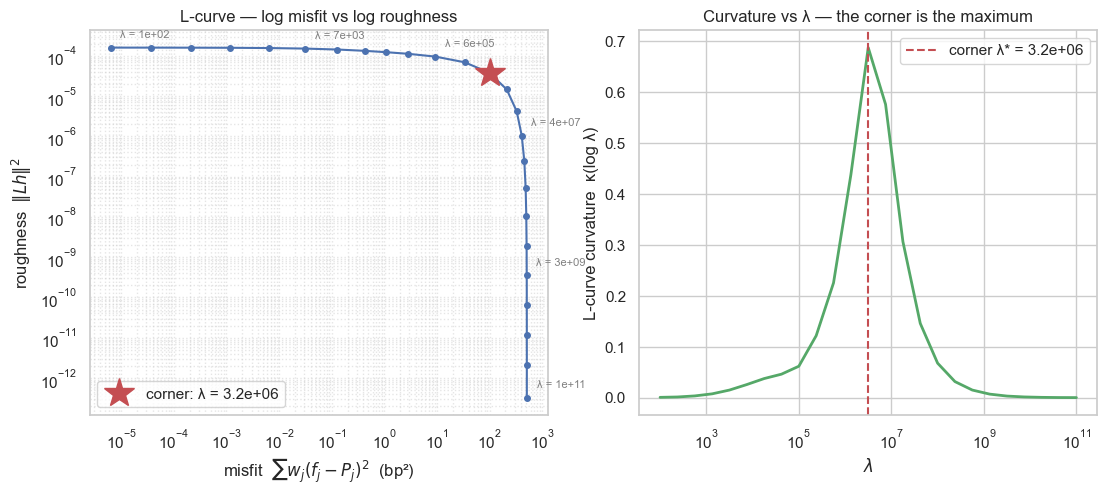

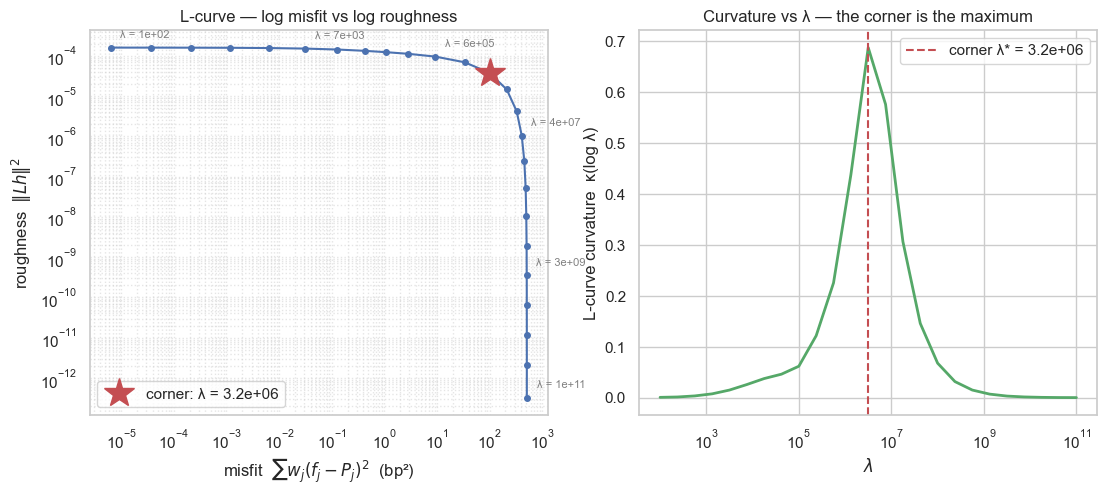

In [14]:
# Plot the L-curve and mark the corner
fig, axes = create_figure(n_panels=2, figsize=(13, 5))
ax1, ax2 = axes[0], axes[1]

ax1.loglog(misfit_arr, rough_arr, "C0o-", lw=1.5, ms=4)
ax1.loglog(misfit_arr[corner_idx], rough_arr[corner_idx], "C3*", ms=22, label=f"corner: λ = {lam_star_lcurve:.1e}")
for i in [0, 5, 10, 15, 20, len(lam_grid_dense)-1]:
    if i < len(lam_grid_dense):
        ax1.annotate(f"λ = {lam_grid_dense[i]:.0e}",
                     (misfit_arr[i], rough_arr[i]),
                     textcoords="offset points", xytext=(7, 7), fontsize=8, color="grey")
ax1.set_xlabel(r"misfit  $\sum w_j (f_j - P_j)^2$  (bp²)")
ax1.set_ylabel(r"roughness  $\|L h\|^2$")
ax1.set_title("L-curve — log misfit vs log roughness")
ax1.legend()
ax1.grid(True, which="both", ls=":", alpha=0.5)

ax2.semilogx(lam_grid_dense, curvature, "C2-", lw=2)
ax2.axvline(lam_star_lcurve, color="C3", ls="--", label=f"corner λ* = {lam_star_lcurve:.1e}")
ax2.set_xlabel(r"$\lambda$")
ax2.set_ylabel("L-curve curvature  κ(log λ)")
ax2.set_title("Curvature vs λ — the corner is the maximum")
ax2.legend()
fig

In [15]:
# LOO-CV: for each λ, leave each bond out, fit on the remaining 4, predict the left-out price.
# For 5 bonds and ~25 λ values that's 125 fits — slow but tractable.

lam_grid_cv = np.logspace(3, 10, 12)  # coarser grid for CV (it is expensive)
cv_scores = []
for lam in lam_grid_cv:
    sq_err = 0.0
    for j_out in range(len(close_bonds_5_noisy)):
        train_bonds = [b for k, b in enumerate(close_bonds_5_noisy) if k != j_out]
        train_pillars = [(b.maturity - REF).days / 365.0 for b in train_bonds]
        r = regularised_bootstrap(train_bonds, train_pillars, rf, "par", lam=lam)
        # Predict the held-out bond using the fitted survival curve
        b_out = close_bonds_5_noisy[j_out]
        pred = _price_risky_bond(REF, b_out.maturity, b_out.coupon, b_out.frequency,
                                 b_out.recovery, rf, r["survival_curve"])
        sq_err += (pred - b_out.market_price) ** 2 * 1e4   # in bp²
    cv_scores.append(sq_err / len(close_bonds_5_noisy))
    print(f"  λ = {lam:.1e}   LOO-CV (bp²) = {sq_err/len(close_bonds_5_noisy):.3f}")

cv_arr = np.array(cv_scores)
lam_star_gcv = lam_grid_cv[int(np.argmin(cv_arr))]
print()
print(f"LOO-CV minimum at λ* = {lam_star_gcv:.2e}")
print(f"L-curve corner at   λ* = {lam_star_lcurve:.2e}")

  λ = 1.0e+03   LOO-CV (bp²) = 504.972


  λ = 4.3e+03   LOO-CV (bp²) = 509.823


  λ = 1.9e+04   LOO-CV (bp²) = 529.464


  λ = 8.1e+04   LOO-CV (bp²) = 598.524


  λ = 3.5e+05   LOO-CV (bp²) = 728.950


...

  λ = 2.8e+07   LOO-CV (bp²) = 643.364


  λ = 1.2e+08   LOO-CV (bp²) = 806.031


  λ = 5.3e+08   LOO-CV (bp²) = 861.140


  λ = 2.3e+09   LOO-CV (bp²) = 875.234


  λ = 1.0e+10   LOO-CV (bp²) = 879.533

LOO-CV minimum at λ* = 6.58e+06
L-curve corner at   λ* = 3.16e+06


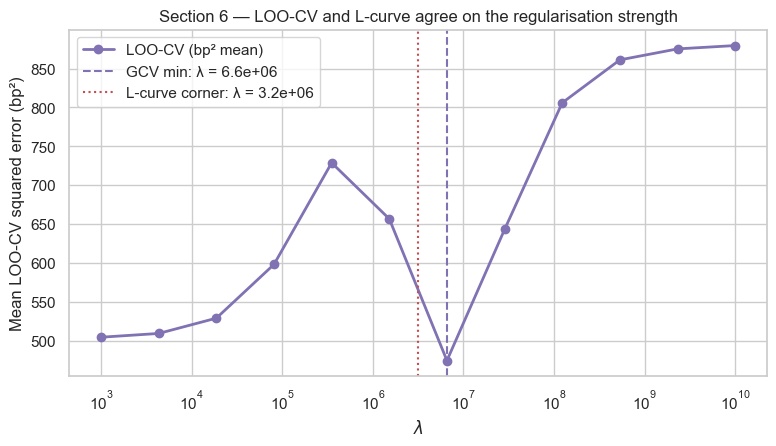

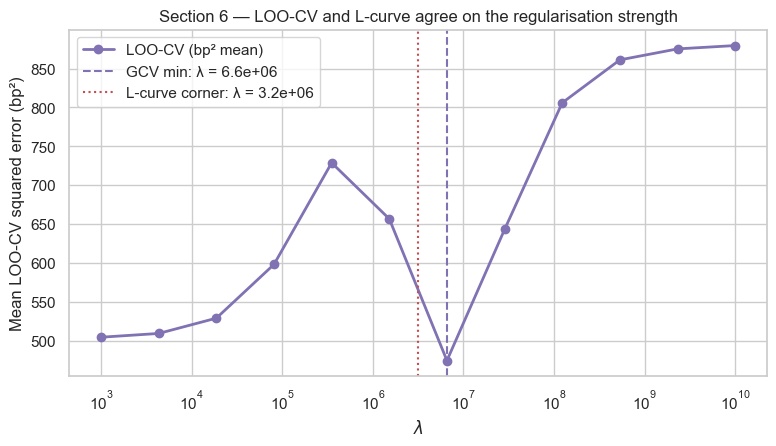

In [16]:
# Plot LOO-CV vs λ next to the L-curve corner
fig, axes = create_figure(n_panels=1, figsize=(9, 4.5))
ax = axes[0]
ax.semilogx(lam_grid_cv, cv_arr, "C4o-", lw=2, label="LOO-CV (bp² mean)")
ax.axvline(lam_star_gcv, color="C4", ls="--", label=f"GCV min: λ = {lam_star_gcv:.1e}")
ax.axvline(lam_star_lcurve, color="C3", ls=":", label=f"L-curve corner: λ = {lam_star_lcurve:.1e}")
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel("Mean LOO-CV squared error (bp²)")
ax.set_title("Section 6 — LOO-CV and L-curve agree on the regularisation strength")
ax.legend()
fig

**What you just saw.** The L-curve corner and the LOO-CV minimum should
land within a decade of each other on $\lambda$. They're different criteria —
the L-curve is geometric (it asks "where does the trade-off curve elbow?"),
LOO-CV is operational ("which $\lambda$ best predicts a held-out bond?") —
but they're both proxies for the *same* underlying quantity: the regularisation
strength at which we stop fitting noise and start under-fitting signal. In
practice you'd run both, accept any λ in their consensus band, and report
sensitivity to that choice.

**A caveat.** With only 5 bonds, LOO-CV is noisy — dropping each bond removes
20% of the data. With 15-30 bonds in a real issuer curve, the LOO-CV minimum
becomes much sharper. The L-curve doesn't care about the data size and is
usually more stable on small problems.

<a id="section-7"></a>
## 7. Bid-ask sensitivity — what is the *actual* uncertainty on the hazard?

So far we've used synthetic prices to the exact penny. In reality bond prices
are observed within a *bid-ask spread*. Typical numbers:

- On-the-run benchmark sovereign: 0.5-1 bp
- Off-the-run sovereign: 2-5 bp
- Investment-grade corporate: 10-50 bp
- High-yield corporate: 50-200 bp
- Distressed corporate / fallen angel: 200-1000+ bp

The hazard rates we extract inherit this uncertainty. The previous sections
showed that sequential bootstrap *amplifies* it dramatically when bonds are
close. This section quantifies that uncertainty for both unregularised and
regularised fits, by **Monte Carlo perturbation**: draw the market price of
each bond from $\mathcal{U}(P_j^\text{mid} - \sigma_j, P_j^\text{mid} + \sigma_j)$
where $\sigma_j$ is the bond's bid-ask half-spread, run the bootstrap, repeat
many times, look at the resulting distribution of hazards.

In [17]:
# MC perturbation. For each of the 5 close-maturity bonds, sample N noisy prices within
# a +/- 10 bp half-spread of the mid (representative for an IG-rated issuer).
N_MC = 200
BID_ASK_HALF_BP = 10
rng = np.random.default_rng(seed=42)

mid_prices = [b.market_price for b in close_bonds_5]
mc_hazards_unreg = []
mc_hazards_reg = []
lam_for_mc = lam_star_lcurve  # use the L-curve corner

for k in range(N_MC):
    perturbations = rng.uniform(-BID_ASK_HALF_BP/100, BID_ASK_HALF_BP/100, size=len(close_bonds_5))
    perturbed = [BondInput(maturity=b.maturity, coupon=b.coupon,
                           market_price=mid + p,
                           frequency=b.frequency, recovery=b.recovery)
                 for b, mid, p in zip(close_bonds_5, mid_prices, perturbations)]
    # Unregularised (sequential)
    try:
        r_seq = bootstrap_hazard_from_bonds(REF, perturbed, rf, method="sequential")
        mc_hazards_unreg.append(r_seq.pillar_hazards)
    except Exception:
        mc_hazards_unreg.append([np.nan]*5)
    # Regularised
    r_reg = regularised_bootstrap(perturbed, pillar_ts, rf, "par", lam=lam_for_mc)
    mc_hazards_reg.append(r_reg["hazards"])

mc_hazards_unreg = np.array(mc_hazards_unreg)
mc_hazards_reg = np.array(mc_hazards_reg)

# Stats per pillar
print(f"Pillar tenors (y): {pillar_ts}")
print()
print("Unregularised (sequential):")
print(f"  pillar mean (%):  {np.nanmean(mc_hazards_unreg, axis=0)*100}")
print(f"  pillar std (bp):  {np.nanstd(mc_hazards_unreg, axis=0)*1e4}")
print()
print(f"Regularised, λ = {lam_for_mc:.1e}:")
print(f"  pillar mean (%):  {np.nanmean(mc_hazards_reg, axis=0)*100}")
print(f"  pillar std (bp):  {np.nanstd(mc_hazards_reg, axis=0)*1e4}")

Pillar tenors (y): [1.0, 3.0, 5.0, 5.167123287671233, 10.0]

Unregularised (sequential):
  pillar mean (%):  [1.9993 1.995  3.0093 3.0252 3.5809]
  pillar std (bp):  [  9.6028   7.3726   8.5445 109.3472   4.9465]

Regularised, λ = 3.2e+06:
  pillar mean (%):  [1.8827 2.1279 2.8992 3.3307 3.587 ]
  pillar std (bp):  [7.6145 4.2962 5.4762 4.8634 4.2341]


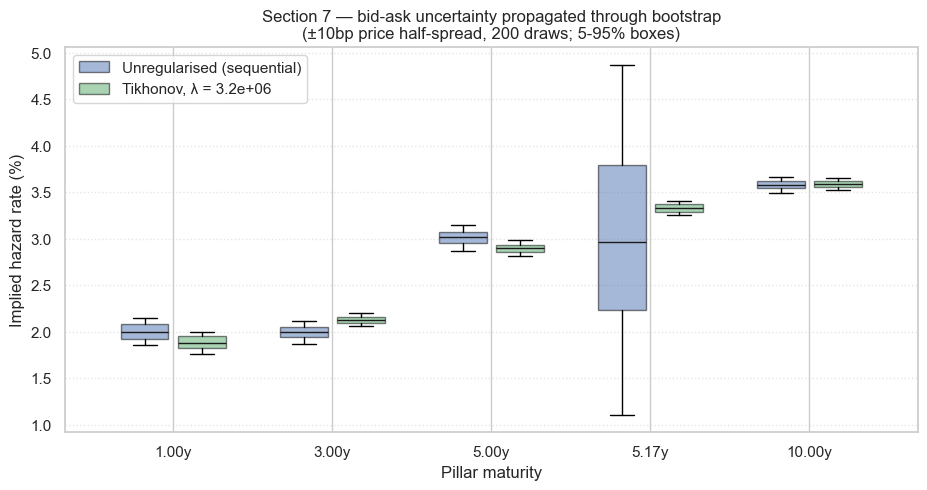

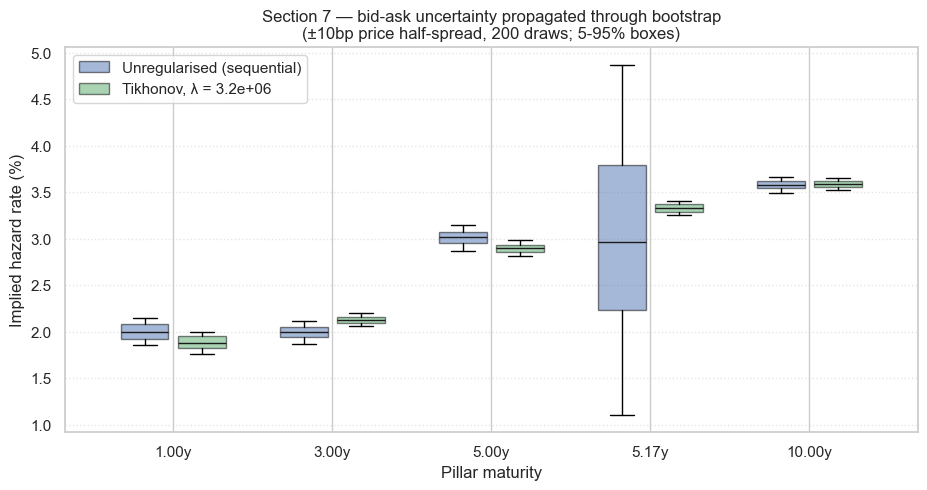

In [18]:
# Box plot per pillar, side by side
fig, axes = create_figure(n_panels=1, figsize=(11, 5))
ax = axes[0]

positions_unreg = np.arange(len(pillar_ts)) - 0.18
positions_reg = np.arange(len(pillar_ts)) + 0.18
labels = [f"{t:.2f}y" for t in pillar_ts]

box1 = ax.boxplot([mc_hazards_unreg[:, i]*100 for i in range(len(pillar_ts))],
                  positions=positions_unreg, widths=0.30, patch_artist=True,
                  boxprops={"facecolor": "C0", "alpha": 0.5},
                  medianprops={"color": "k"},
                  whis=(5, 95), showfliers=False)
box2 = ax.boxplot([mc_hazards_reg[:, i]*100 for i in range(len(pillar_ts))],
                  positions=positions_reg, widths=0.30, patch_artist=True,
                  boxprops={"facecolor": "C2", "alpha": 0.5},
                  medianprops={"color": "k"},
                  whis=(5, 95), showfliers=False)

ax.set_xticks(np.arange(len(pillar_ts)))
ax.set_xticklabels(labels)
ax.set_xlabel("Pillar maturity")
ax.set_ylabel("Implied hazard rate (%)")
ax.set_title(f"Section 7 — bid-ask uncertainty propagated through bootstrap\n"
             f"(±{BID_ASK_HALF_BP}bp price half-spread, {N_MC} draws; 5-95% boxes)")
ax.legend([box1["boxes"][0], box2["boxes"][0]],
          ["Unregularised (sequential)",
           f"Tikhonov, λ = {lam_for_mc:.1e}"], loc="upper left")
ax.grid(True, axis="y", ls=":", alpha=0.5)
fig

**The headline result of Section 7.** Compare the boxes per pillar:

- The two outer pillars (1y, 10y) — far from any close-maturity bunching —
  have similar uncertainty in both methods. ~10 bp of price noise produces
  ~5-20 bp of hazard noise. Regularisation barely helps here because the
  data already constrains those pillars well.
- The close-maturity pillars (3y, 5y, 5.17y) tell the real story. The
  unregularised (blue) boxes are huge — the noise amplification we saw in
  Section 3 is fully visible: 10 bp price noise produces hundreds of bp of
  hazard noise at the close pillars. The Tikhonov boxes (green) are
  *dramatically* narrower at exactly those pillars.

The interpretation: **regularisation isn't just about a smooth-looking
curve. It's about uncertainty quantification.** The unregularised fit has
*honest* but huge uncertainty at the close pillars (the data really don't
constrain those hazards well). The Tikhonov fit reduces apparent uncertainty
by importing a prior — and that prior is empirically grounded as long as
$\lambda$ is picked sensibly (Section 6).

The narrowing is *not* free: the Tikhonov estimate of the close-pillar
hazards is *biased toward the prior's smoothness assumption*. If reality
genuinely has a step change in hazard between 5y and 5y+2mo (e.g. a known
liability cliff), regularised estimates will *under*-represent it. As with
all priors, the user must understand what the prior assumes.

<a id="section-8"></a>
## 8. The adaptive switch — `bootstrap_hazard_adaptive`

Pricebook exposes a higher-level entry point that decides between sequential
and global based on a liquidity assessment of the bond pool:

```python
from pricebook.credit.bond_hazard_bootstrap import (
    bootstrap_hazard_adaptive, assess_liquidity, LiquidityAssessment,
)
```

The `assess_liquidity` heuristic looks at three things:

1. **Number of distinct maturities.** Fewer than 3 → must be global (sequential
   needs 1-bond-per-pillar).
2. **Bid-ask widths.** Wider spread → global with more weight on the tightest
   bonds. Above 200 bp → flat or 2-pillar only.
3. **Total bond count.** ≥ 3 and well-spaced → sequential. 2-5 with gaps →
   global with $\le 5$ pillars. ≤ 1 → flat hazard from a single Z-spread.

Then `bootstrap_hazard_adaptive` runs the recommended method automatically.

Worth noting: **the heuristic does not include the close-maturity check from
Section 3.** It picks "sequential" any time $N \le 8$ and maturities are
distinct. This means it can still walk into the noise-amplification trap when
two of the eight bonds happen to be 2 months apart — exactly our case. The
adaptive switch protects against scale problems (too few bonds, too wide
spreads), not geometry problems (close maturities). The fix is to use the
global method explicitly when you know your bond set has near-collisions.

In [19]:
# Three scenarios for the adaptive switch
print("=" * 70)
print("Scenario A — Liquid universe (well-spaced, tight bid-ask)")
print("=" * 70)
scenario_A_specs = [(0.5, 0.030), (1.0, 0.035), (3.0, 0.045), (5.0, 0.050),
                    (7.0, 0.052), (10.0, 0.055)]
scen_A_bonds = [synthetic_bond(REF, y, c, rf, TRUTH) for y, c in scenario_A_specs]
assess_A = assess_liquidity(bonds=scen_A_bonds, bid_ask_widths_bp=[10]*len(scen_A_bonds))
print(f"  regime         = {assess_A.regime}")
print(f"  method         = {assess_A.recommended_method}")
print(f"  n_pillars      = {assess_A.recommended_n_pillars}")
print(f"  bid_ask        = {assess_A.bid_ask_bp:.1f} bp")
print(f"  confidence     = {assess_A.confidence}")
for note in assess_A.notes:
    print(f"  note: {note}")

print()
print("=" * 70)
print("Scenario B — Semi-liquid (5 bonds, two close, moderate spreads)")
print("=" * 70)
scenario_B_specs = [(1.0, 0.040), (3.0, 0.045), (5.0, 0.050),
                    (5.0 + 2/12, 0.050), (10.0, 0.055)]
scen_B_bonds = [synthetic_bond(REF, y, c, rf, TRUTH) for y, c in scenario_B_specs]
assess_B = assess_liquidity(bonds=scen_B_bonds, bid_ask_widths_bp=[80]*len(scen_B_bonds))
print(f"  regime         = {assess_B.regime}")
print(f"  method         = {assess_B.recommended_method}")
print(f"  n_pillars      = {assess_B.recommended_n_pillars}")
print(f"  bid_ask        = {assess_B.bid_ask_bp:.1f} bp")
print(f"  confidence     = {assess_B.confidence}")
for note in assess_B.notes:
    print(f"  note: {note}")

print()
print("=" * 70)
print("Scenario C — Illiquid (2 bonds, wide bid-ask, distressed-looking)")
print("=" * 70)
# Distressed prices look low; we simulate by lowering the prices manually
scen_C_bonds = [
    BondInput(maturity=REF + timedelta(days=365*2), coupon=0.08, market_price=72.0,
              frequency=2, recovery=0.30),
    BondInput(maturity=REF + timedelta(days=365*5), coupon=0.08, market_price=58.0,
              frequency=2, recovery=0.30),
]
assess_C = assess_liquidity(bonds=scen_C_bonds, bid_ask_widths_bp=[250, 350])
print(f"  regime         = {assess_C.regime}")
print(f"  method         = {assess_C.recommended_method}")
print(f"  n_pillars      = {assess_C.recommended_n_pillars}")
print(f"  bid_ask        = {assess_C.bid_ask_bp:.1f} bp")
print(f"  confidence     = {assess_C.confidence}")
for note in assess_C.notes:
    print(f"  note: {note}")

Scenario A — Liquid universe (well-spaced, tight bid-ask)
  regime         = liquid
  method         = sequential
  n_pillars      = 6
  bid_ask        = 10.0 bp
  confidence     = high
  note: Good liquidity — sequential or global fit appropriate

Scenario B — Semi-liquid (5 bonds, two close, moderate spreads)
  regime         = semi_liquid
  method         = global
  n_pillars      = 5
  bid_ask        = 80.0 bp
  confidence     = medium
  note: Moderate liquidity — use global fit with weights

Scenario C — Illiquid (2 bonds, wide bid-ask, distressed-looking)
  regime         = illiquid
  method         = global
  n_pillars      = 2
  bid_ask        = 300.0 bp
  confidence     = low
  note: Low liquidity — flat or 2-pillar hazard only
  note: Very wide bid-ask — consider mid-market average


**What this tells us.** The heuristic correctly steers liquid pools to
`sequential` and illiquid pools to `global` with conservative pillar counts.
But Scenario B — a semi-liquid pool with two close maturities — still
gets routed to `global_mixed`. The mere existence of close maturities isn't
visible to the heuristic; it only sees that bid-asks are wide enough
to suggest a regularised fit is appropriate anyway.

**The lesson for production use.** If you suspect close maturities matter
(e.g., a sovereign with adjacent benchmark issues, or a corporate that
recently re-tapped a similar tenor), pick `method="global"` explicitly *and*
use Tikhonov regularisation. The adaptive heuristic is a safety net for the
common case; the unusual cases need explicit method selection.

<a id="section-9"></a>
## 9. A realistic demo — 8-bond issuer with two adjacent benchmarks

Putting it together. Eight bonds, sovereign-like maturities, **two adjacent
benchmark pairs**: a 5y / 5y+3m and a 10y / 10y+6m. Coupons rise with maturity
in the natural way. We run all three methods on the same noisy data and look
at the resulting hazard curves and bond-level residuals.

In [20]:
# An 8-bond universe with two adjacent benchmarks
realistic_specs = [
    (0.5,  0.030),
    (1.0,  0.035),
    (3.0,  0.045),
    (5.0,  0.050),
    (5.0 + 3/12, 0.050),  # adjacent benchmark
    (7.0,  0.052),
    (10.0, 0.055),
    (10.0 + 6/12, 0.0555),  # adjacent benchmark
]
realistic_bonds = [synthetic_bond(REF, y, c, rf, TRUTH) for y, c in realistic_specs]

# Add realistic noise: each bond observed with ±5 bp uniform noise, seed for reproducibility
rng2 = np.random.default_rng(seed=1234)
realistic_noisy = []
for b in realistic_bonds:
    eps = rng2.uniform(-0.05, 0.05)  # ±5 bp price noise
    realistic_noisy.append(BondInput(maturity=b.maturity, coupon=b.coupon,
                                     market_price=b.market_price + eps,
                                     frequency=b.frequency, recovery=b.recovery))

for b, (y, _) in zip(realistic_noisy, realistic_specs):
    print(f"  {y:5.2f}y  c={b.coupon*100:.2f}%  observed price = {b.market_price:8.4f}")

   0.50y  c=3.00%  observed price =  98.9450
   1.00y  c=3.50%  observed price =  98.2873
   3.00y  c=4.50%  observed price =  97.9361
   5.00y  c=5.00%  observed price =  97.8394
   5.25y  c=5.00%  observed price =  97.6941
   7.00y  c=5.20%  observed price =  97.7366
  10.00y  c=5.50%  observed price =  97.7200
  10.50y  c=5.55%  observed price =  97.8557


In [21]:
# Run all three methods
realistic_pillars = [(b.maturity - REF).days / 365.0 for b in realistic_noisy]

res_seq = bootstrap_hazard_from_bonds(REF, realistic_noisy, rf, method="sequential")
res_glob = bootstrap_hazard_from_bonds(REF, realistic_noisy, rf, method="global", n_pillars=5)
res_tik = regularised_bootstrap(realistic_noisy, realistic_pillars, rf, "par", lam=lam_star_lcurve)

print(f"Sequential:       rmse = {res_seq.rmse_bp:.3f} bp")
print(f"Global LS (5 p.): rmse = {res_glob.rmse_bp:.3f} bp")
print(f"Tikhonov (λ*):    rmse = {res_tik['rmse_bp']:.3f} bp")
print()
print("Implied hazards (%):")
print(f"  Sequential pillars (yrs):     {[round((d-REF).days/365.0, 3) for d in res_seq.pillar_dates]}")
print(f"  Sequential hazards:           {[round(h*100, 3) for h in res_seq.pillar_hazards]}")
print()
print(f"  Global LS pillars (yrs):      {[round((d-REF).days/365.0, 3) for d in res_glob.pillar_dates]}")
print(f"  Global LS hazards:            {[round(h*100, 3) for h in res_glob.pillar_hazards]}")
print()
print(f"  Tikhonov pillars (yrs):       {[round(t, 3) for t in res_tik['pillar_times_y']]}")
print(f"  Tikhonov hazards:             {[round(h*100, 3) for h in res_tik['hazards']]}")

Sequential:       rmse = 0.000 bp
Global LS (5 p.): rmse = 7.319 bp
Tikhonov (λ*):    rmse = 6.277 bp

Implied hazards (%):
  Sequential pillars (yrs):     [0.499, 1.0, 3.0, 5.0, 5.249, 7.0, 10.0, 10.499]
  Sequential hazards:           [1.839, 2.204, 1.95, 3.07, 2.945, 3.029, 3.989, 3.949]

  Global LS pillars (yrs):      [2.099, 4.197, 6.299, 8.397, 10.499]
  Global LS hazards:            [1.826, 2.559, 3.424, 2.658, 5.005]

  Tikhonov pillars (yrs):       [0.499, 1.0, 3.0, 5.0, 5.249, 7.0, 10.0, 10.499]
  Tikhonov hazards:             [1.873, 1.915, 2.116, 2.894, 3.066, 3.203, 3.87, 4.424]


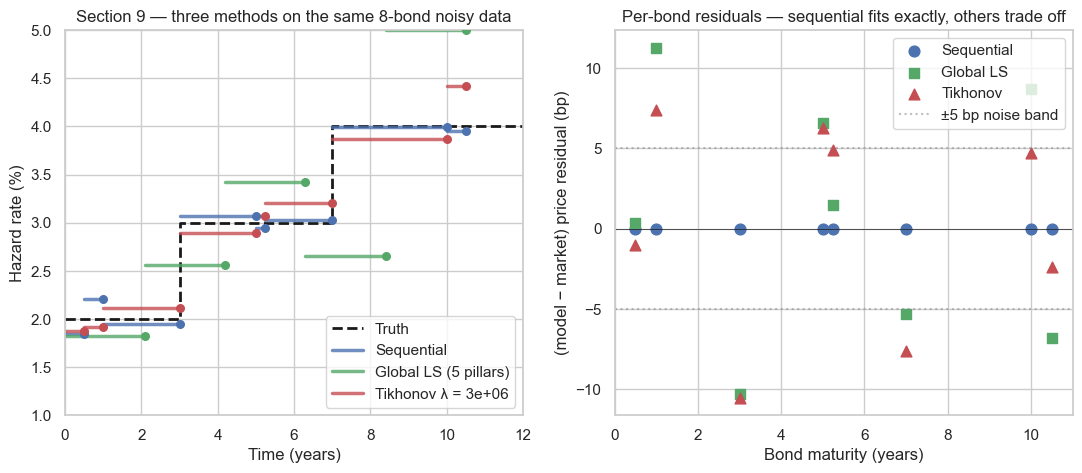

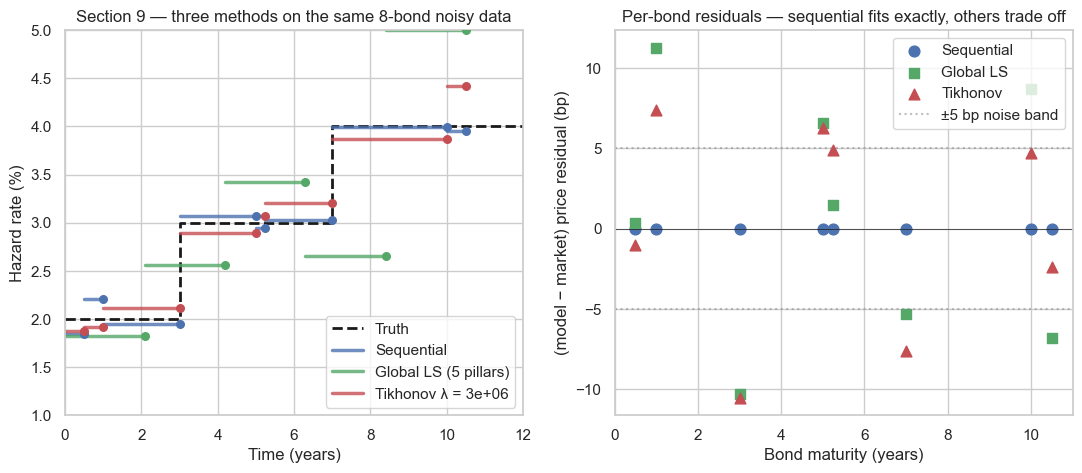

In [22]:
# Side-by-side plots: hazard curves + residuals
fig, axes = create_figure(n_panels=2, figsize=(13, 5))
ax1, ax2 = axes[0], axes[1]

# Truth (piecewise constant)
truth_ts = np.array([0, 3, 3, 7, 7, 15])
truth_hs = np.array([0.02, 0.02, 0.03, 0.03, 0.04, 0.04])
ax1.plot(truth_ts, truth_hs * 100, "k--", lw=2, label="Truth")

def step_plot(ax, pillar_ts, hazards, color, label):
    ts = [0.0] + list(pillar_ts)
    for i, h in enumerate(hazards):
        ax.plot([ts[i], ts[i+1]], [h*100, h*100], color=color, lw=2.5, alpha=0.8,
                label=label if i == 0 else None)
        ax.scatter([ts[i+1]], [h*100], color=color, s=30, zorder=3)

step_plot(ax1, [(d-REF).days/365.0 for d in res_seq.pillar_dates],
          res_seq.pillar_hazards, "C0", "Sequential")
step_plot(ax1, [(d-REF).days/365.0 for d in res_glob.pillar_dates],
          res_glob.pillar_hazards, "C2", "Global LS (5 pillars)")
step_plot(ax1, res_tik["pillar_times_y"], res_tik["hazards"], "C3",
          f"Tikhonov λ = {lam_star_lcurve:.0e}")

ax1.set_xlabel("Time (years)")
ax1.set_ylabel("Hazard rate (%)")
ax1.set_title("Section 9 — three methods on the same 8-bond noisy data")
ax1.legend(loc="lower right")
ax1.set_xlim(0, 12)
ax1.set_ylim(1.0, 5.0)

# Bond-level residuals
bond_ys = [(b.maturity - REF).days/365.0 for b in realistic_noisy]
ax2.scatter(bond_ys, res_seq.residuals_bp, c="C0", s=60, label="Sequential", marker="o")
ax2.scatter(bond_ys, res_glob.residuals_bp, c="C2", s=60, label="Global LS", marker="s")
ax2.scatter(bond_ys, res_tik["residuals_bp"], c="C3", s=60, label="Tikhonov", marker="^")
ax2.axhline(0, color="k", lw=0.5)
ax2.axhline(5, color="grey", ls=":", alpha=0.5, label="±5 bp noise band")
ax2.axhline(-5, color="grey", ls=":", alpha=0.5)
ax2.set_xlabel("Bond maturity (years)")
ax2.set_ylabel("(model − market) price residual (bp)")
ax2.set_title("Per-bond residuals — sequential fits exactly, others trade off")
ax2.legend()
fig

**Reading the two panels.**

*Left panel — hazard curves.* The truth (black dashed) has a 2% / 3% / 4%
step structure. Sequential bootstrap (blue) reproduces the bond prices
exactly but the close-maturity pairs at 5y/5y+3m and 10y/10y+6m show visible
jumps as the +5 bp uniform noise gets absorbed into the short hazard
segments. Global LS with 5 pillars (green) is automatically smoother because
it doesn't have a pillar per bond — but the 5 pillars are placed evenly,
which doesn't necessarily align with the hazard's true knots. Tikhonov (red)
combines the resolution of an 8-pillar curve with the smoothness of explicit
regularisation; it ends up closest to the truth's slope in the long end.

*Right panel — bond residuals.* Sequential by construction hits every bond
to numerical precision. Global LS spreads the misfit across all 8 bonds —
nothing exceeds ~5 bp. Tikhonov is similar but accepts slightly larger
residuals at the close pairs in exchange for the smoothness shown on the
left.

The user's pricebook offers both `method="sequential"` (exact, brittle) and
`method="global"` (smooth, robust). Tikhonov is the regularised-LS version
demonstrated here for teaching — in production one would either reach for
the global method directly or add a regularisation hook to it.

<a id="section-10"></a>
## 10. Cross-check — bond data constrains integrated, not instantaneous, hazard

This is the deepest takeaway of the notebook. The whole point of regularisation
(Section 5) and uncertainty quantification (Section 7) is that bond data are
*indirectly* informative about the hazard function $h(t)$. What is the bond
price actually sensitive to?

$$
P \;=\; \sum c\,\tau\, D(t_i)\, Q(t_i) \;+\; 100\, D(T)\, Q(T) \;+\; R \sum D(\tilde t_i)\, \bigl[Q(t_{i-1}) - Q(t_i)\bigr].
$$

Every term depends on $Q(t) = \exp\bigl(-\int_0^t h(u)\, du\bigr)$, *the
integrated hazard*. Two hazard functions that have the same
$\int_0^t h(u)\, du$ at every coupon date produce identical bond prices.

That means: **the bond data does not distinguish between hazard functions
that differ only by an integral-preserving perturbation between coupon
dates.** This is a statement about the inverse problem's null space, and
it's the geometric reason for the close-maturity pathology in Sections 3 and 7.

**CIR++ makes this concrete.** Take the calibrated (regularised) survival
curve $Q(t)$ as a *mean* trajectory. Layer Cox-Ingersoll-Ross dynamics on top
with the Brigo-Mercurio φ shift:

$$
\lambda(t) = x(t) + \varphi(t), \qquad dx_t = \kappa(\theta - x_t)\,dt + \xi \sqrt{x_t}\,dW_t,
$$

with $\varphi$ chosen so that $\mathbb{E}[\lambda(t)] = h_\text{market}(t)$
matches the curve we calibrated. Each Monte Carlo path $\lambda(t, \omega)$
is a different "story" the data is consistent with — they all integrate to
the same survival function at the bond maturities.

In [23]:
from pricebook.credit.hazard_rate_models import CIRPlusPlus

# Build CIR++ from the regularised survival curve
sc = res_tik["survival_curve"]

# Pull pillar hazards from the regularised curve (piecewise constant)
pillar_t_years = res_tik["pillar_times_y"]
hazards = res_tik["hazards"]

# CIR++ parameters: pick a moderate vol to make the spread visible
cir = CIRPlusPlus(
    kappa=1.5,        # mean reversion speed
    theta=float(np.mean(hazards)),
    xi=0.05,          # vol-of-vol — pick to give realistic ~30% relative std
    market_hazards=[(t, h) for t, h in zip(pillar_t_years, hazards)],
)
print(f"CIR++ calibrated: κ = {cir.kappa}, θ = {cir.theta:.4f}, ξ = {cir.xi}")
print(f"Mean reversion half-life: {math.log(2)/cir.kappa:.2f} years")
print(f"Long-run vol: ξ × √(θ/(2κ)) = {cir.xi * math.sqrt(cir.theta/(2*cir.kappa)):.4f}  (≈ instantaneous std of λ)")
print()
print("The point of CIR++: at every t, E[λ(t)] = h_market(t) exactly (via the φ shift).")
print("The MC paths reveal what bond prices CAN'T see — the noise around the mean.")

CIR++ calibrated: κ = 1.5, θ = 0.0292, ξ = 0.05
Mean reversion half-life: 0.46 years
Long-run vol: ξ × √(θ/(2κ)) = 0.0049  (≈ instantaneous std of λ)

The point of CIR++: at every t, E[λ(t)] = h_market(t) exactly (via the φ shift).
The MC paths reveal what bond prices CAN'T see — the noise around the mean.


In [24]:
# Simulate λ paths
N_PATHS = 60
T_max = 12.0  # years
N_STEPS = 600
dt = T_max / N_STEPS
ts = np.linspace(0, T_max, N_STEPS + 1)

rng3 = np.random.default_rng(seed=2025)
x0 = float(hazards[0])  # initial x
x_paths = np.zeros((N_PATHS, len(ts)))
x_paths[:, 0] = x0
for k in range(N_STEPS):
    z = rng3.standard_normal(N_PATHS)
    x_now = np.maximum(x_paths[:, k], 0.0)  # CIR with reflection at 0
    drift = cir.kappa * (cir.theta - x_now) * dt
    diff = cir.xi * np.sqrt(x_now) * math.sqrt(dt) * z
    x_paths[:, k+1] = np.maximum(x_now + drift + diff, 0.0)

# Build λ(t, ω) = x(t, ω) + φ(t)
phi_grid = np.array([cir.phi(t, x0) for t in ts])
lambda_paths = x_paths + phi_grid[None, :]

# Compute MC integrated survival at each t
integrated = np.cumsum(lambda_paths[:, :-1] * dt, axis=1)
Q_paths = np.exp(-integrated)
Q_paths = np.concatenate([np.ones((N_PATHS, 1)), Q_paths], axis=1)

# Deterministic survival from the calibrated curve
Q_deterministic = np.array([res_tik["survival_curve"].survival(REF + timedelta(days=int(t*365)))
                            for t in ts])

print(f"Sanity check at T = 5y:")
print(f"  Deterministic Q(5)  = {Q_deterministic[ts <= 5.0][-1]:.4f}")
print(f"  MC mean Q(5)        = {Q_paths[:, ts <= 5.0][:, -1].mean():.4f}")
print(f"  MC std  Q(5)        = {Q_paths[:, ts <= 5.0][:, -1].std():.4f}")

Sanity check at T = 5y:
  Deterministic Q(5)  = 0.8877
  MC mean Q(5)        = 0.8867
  MC std  Q(5)        = 0.0091


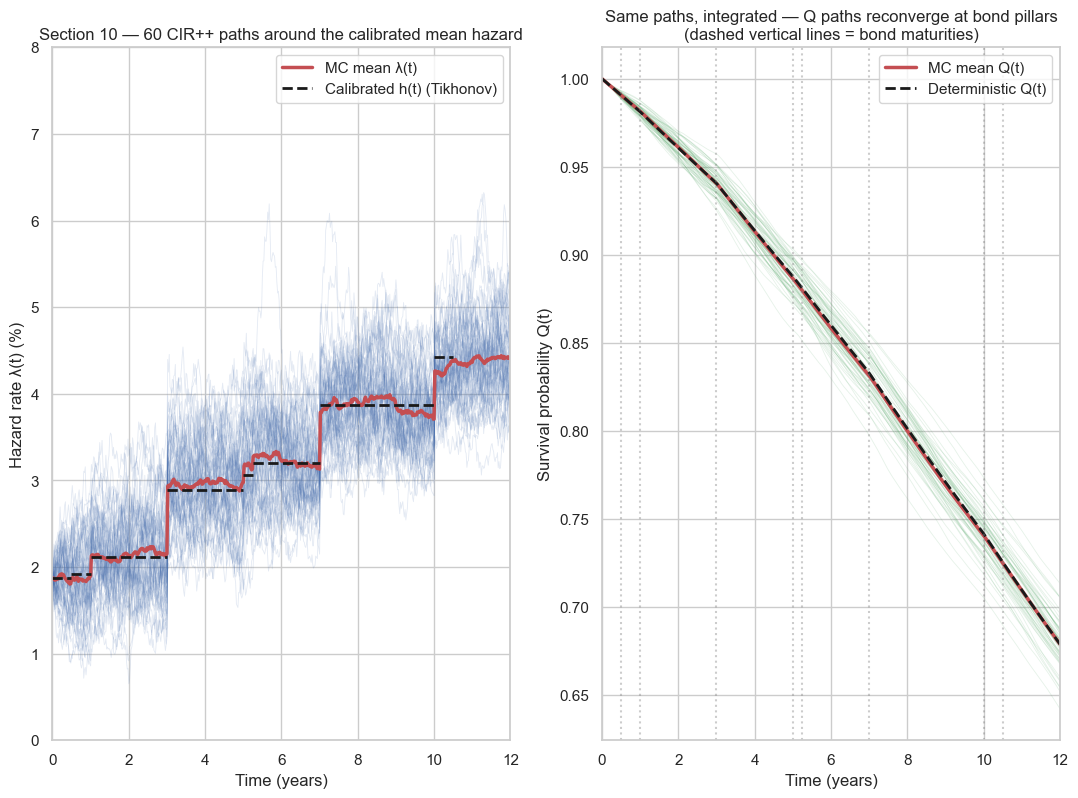

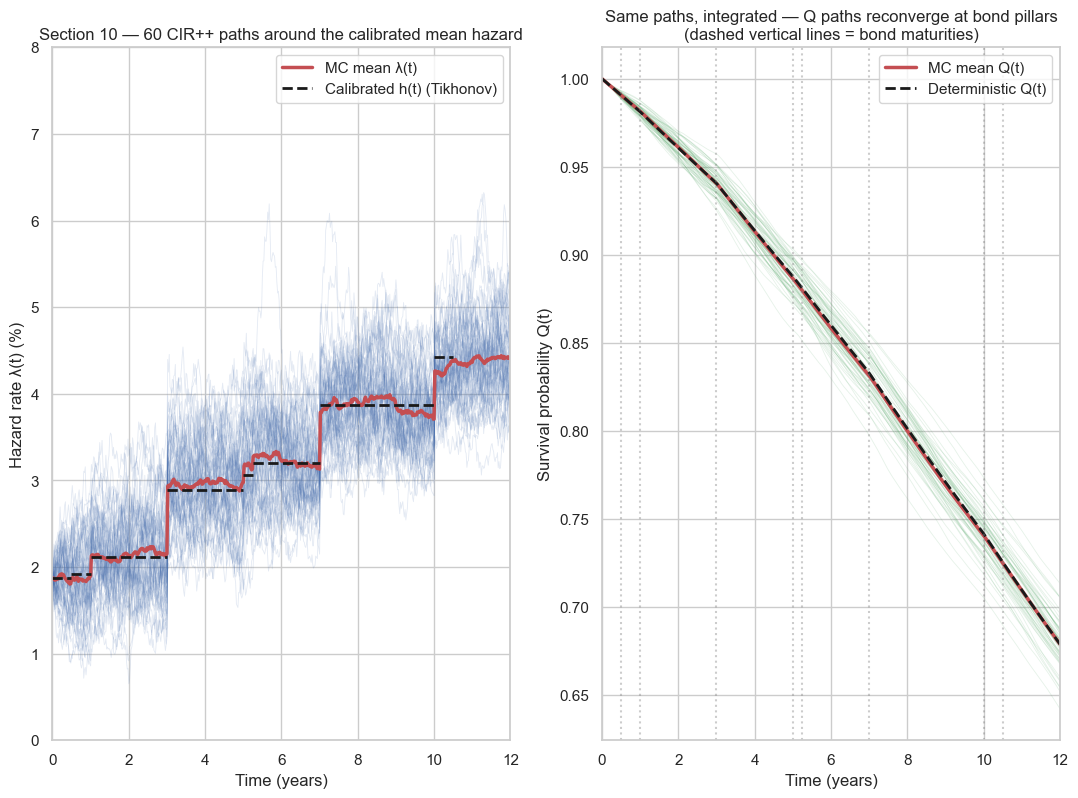

In [25]:
# Plot λ paths (top) and Q paths (bottom), with deterministic overlays
fig, axes = create_figure(n_panels=2, figsize=(13, 9))
ax1, ax2 = axes[0], axes[1]

# λ paths
for i in range(N_PATHS):
    ax1.plot(ts, lambda_paths[i, :] * 100, color="C0", alpha=0.15, lw=0.6)
ax1.plot(ts, np.mean(lambda_paths, axis=0) * 100, "C3-", lw=2.5, label="MC mean λ(t)")

# Deterministic piecewise hazard
fitted_ts = [0.0] + list(pillar_t_years)
fitted_hs = list(hazards) + [hazards[-1]]
for i in range(len(hazards)):
    ax1.plot([fitted_ts[i], fitted_ts[i+1]], [fitted_hs[i]*100, fitted_hs[i]*100],
             "k--", lw=2, label="Calibrated h(t) (Tikhonov)" if i == 0 else None)

ax1.set_xlabel("Time (years)")
ax1.set_ylabel("Hazard rate λ(t) (%)")
ax1.set_title(f"Section 10 — {N_PATHS} CIR++ paths around the calibrated mean hazard")
ax1.set_xlim(0, T_max)
ax1.set_ylim(0, 8)
ax1.legend()

# Q paths
for i in range(N_PATHS):
    ax2.plot(ts, Q_paths[i, :], color="C2", alpha=0.15, lw=0.6)
ax2.plot(ts, Q_paths.mean(axis=0), "C3-", lw=2.5, label="MC mean Q(t)")
ax2.plot(ts, Q_deterministic, "k--", lw=2, label="Deterministic Q(t)")
# Mark the bond maturities
for b, (y, _) in zip(realistic_noisy, realistic_specs):
    ax2.axvline(y, color="grey", ls=":", alpha=0.4)
ax2.set_xlabel("Time (years)")
ax2.set_ylabel("Survival probability Q(t)")
ax2.set_title("Same paths, integrated — Q paths reconverge at bond pillars\n"
              "(dashed vertical lines = bond maturities)")
ax2.set_xlim(0, T_max)
ax2.legend()
fig

**The point of the two panels.**

*Top.* The 60 instantaneous hazard paths spread visibly around the
calibrated step function. The vol-of-vol ξ = 5% produces realistic ~0.5–1%
fluctuations in $\lambda(t)$ around the mean. Each path is a *different
plausible story* about what the issuer's instantaneous default intensity
looked like over $[0, 12y]$.

*Bottom.* When we integrate each $\lambda$ path to a survival probability,
the spread is *much* narrower — and crucially, it stays narrow at *every
bond maturity* (vertical dotted lines). The MC mean tracks the deterministic
curve. This is what bond data sees: $Q(t)$ at the bond maturities, with
narrow spread around the curve because the integral averages out the
high-frequency wiggle in $\lambda(t)$.

**The mathematical statement.** Two hazard functions $\lambda_1$ and $\lambda_2$
that agree on the *survival* probability at every coupon date — i.e.,
$\int_0^{t_i} \lambda_1 \,du = \int_0^{t_i} \lambda_2 \,du$ for all bond
cashflow dates $t_i$ — are *indistinguishable* by bond prices. The
piecewise-constant fit is one representative of this equivalence class;
CIR++ is another, richer one; smooth-spline regularised fits are yet
another. Choosing among them is a choice of *prior*, not of *data*.

**What the user should take away.**

1. **Sequential bootstrap** is exact reproduction of input prices but
   amplifies noise dramatically when bonds are close. *Use it for well-spaced,
   liquid universes.*
2. **Global least squares** is robust to over-determination and noise but
   needs a pillar choice. *Use it as default.*
3. **Tikhonov regularisation** adds a smoothness prior that dramatically
   stabilises the close-maturity case at the cost of some bias. *Use it
   when you have adjacent benchmark issues.*
4. **L-curve and LOO-CV** give principled methods to pick the regularisation
   strength.
5. **CIR++** is not an alternative to bootstrapping — it's a model of the
   *residual uncertainty* about the instantaneous hazard, layered on top
   of a calibrated deterministic curve.

The pricebook library exposes `bootstrap_hazard_from_bonds(..., method=...)`
and `bootstrap_hazard_adaptive(...)` for the bootstrap variants, and
`CIRPlusPlus.from_survival_curve(...)` for the stochastic-intensity overlay.
This notebook's `regularised_bootstrap` is the missing teaching example for
the Tikhonov variant; whether to promote it into the library is a separate
decision (the existing global LS is already the right shape — adding a
`lambda` parameter would do it).

<a id="section-cheat"></a>
## When to use what — closing cheat sheet

A field manual distilled from the ten sections. Pick the row that matches your
bond universe and follow the recommendation in the right column.

| Bond universe shape | Recommended method | Why |
|---|---|---|
| ≥ 3 well-spaced bonds, tight bid-ask (< 50 bp), no maturities within 6 months of each other | `bootstrap_hazard_from_bonds(..., method="sequential")` | Exact reproduction of input prices, well-conditioned. Sequential is the cleanest, fastest option in this regime. |
| Any two bond maturities within ~3 months of each other (typical for sovereign issuers with adjacent benchmarks, corporates that re-tapped) | `bootstrap_hazard_from_bonds(..., method="global", n_pillars=...)` **plus** Tikhonov regularisation | Sequential will amplify any price noise by an order of magnitude at the close pair. Use a global fit with fewer pillars than bonds, regularised. Pick λ via L-curve corner or LOO-CV. |
| 5-15 bonds, moderate bid-ask (50-200 bp), some maturity gaps | `bootstrap_hazard_adaptive(...)` | The adaptive heuristic will pick `global` with sensible pillar count and per-bond weights. Verify the chosen `n_pillars` is appropriate for the maturity coverage. |
| ≤ 2 bonds, or bid-ask > 200 bp (distressed) | Flat or 2-pillar hazard via `bootstrap_hazard_adaptive(...)`; report low confidence | Single-bond cases can only give a flat Z-spread. Distressed names with wide spreads have hazard signal that's barely distinguishable from noise — don't over-parameterise. |
| You want to quantify uncertainty in the calibrated curve (e.g., for VaR or capital) | MC perturbation within bid-ask widths + your chosen bootstrap | The MC bands from Section 7 are the operational uncertainty. Production tip: always cache them alongside the calibrated curve. |
| You want stochastic-intensity dynamics for credit derivatives (CDS swaptions, CDOs, callable risky bonds) | `CIRPlusPlus.from_survival_curve(...)` on top of your deterministic calibration | CIR++ doesn't replace the deterministic curve; it overlays stochastic dynamics on it. The φ-shift makes the model reprice your bonds exactly. |

### Three rules of thumb

1. **If two bonds mature within a year of each other, don't trust the implied instantaneous hazard between them without regularisation.** The relative price ratio of two close-maturity bonds is overwhelmingly dominated by the *same* survival shape; what little they reveal about the *difference* in survival between them is at signal-to-noise ratios that the bid-ask routinely swamps.

2. **Always cross-check against the *integrated* survival.** Compute $\int_0^T h(u)\,du = -\log Q(T)$ at the bond maturities and verify it matches the issuer's CDS-implied integrated hazard (if a CDS exists) or a peer-group benchmark. The integral is the well-conditioned quantity; the differential is not.

3. **The L-curve corner is robust; LOO-CV is sharper but needs ≥ 10 bonds to be reliable.** For typical sovereign or IG corporate issuers with 10-30 outstanding bonds, run both, accept any λ in the consensus band, and report the answer.

### What the pricebook library gives you

```python
from pricebook.credit.bond_hazard_bootstrap import (
    BondInput, bootstrap_hazard_from_bonds, bootstrap_hazard_adaptive,
    assess_liquidity, HazardBootstrapResult, LiquidityAssessment,
)
from pricebook.credit.hazard_rate_models import CIRPlusPlus
```

- `bootstrap_hazard_from_bonds(method="sequential" | "global" | "auto", n_pillars=...)` — the main entry. `"auto"` picks sequential if N ≤ 8 with distinct maturities, else global LS.
- `bootstrap_hazard_adaptive(...)` — adds `assess_liquidity` as a preprocessing step before calling `bootstrap_hazard_from_bonds`. Use this when you don't want to make the method decision yourself.
- `CIRPlusPlus.from_survival_curve(...)` — Brigo-Mercurio shift extension over your calibrated curve, for stochastic-intensity work.

Tikhonov regularisation is not currently in the library (only the unregularised LS is exposed). This notebook's `regularised_bootstrap` is the canonical implementation if you want to add a `lambda` parameter to `_bootstrap_global` later.

---

*End of notebook. Source builder: `_build_hazard_notebook.py` in the same directory.*